# Phase 2: Transcriptomic DGE, GSEA, decoupleR+DoRothEA TF Activity, CNV, Mutational Signatures & SV Profiling

**Project:** Comparative Multi-Omics & Clinical Profiling: Genomically Stable (GS) vs. Chromosomal Instable (CIN) Gastric Cancer  
**Dataset:** TCGA-STAD (*Nature* 2014) & GDC STAR Unstranded RNA-seq Counts ($N=190$ samples: $136$ CIN, $54$ GS)  

---

## 🔬 Overview & Key Objectives
This notebook executes **Phase 2** of the multi-omics workflow:
1. **Unstranded STAR Count Ingestion**: Load raw integer count matrix directly from GDC API / TCGABiolinks aligned with curated GS vs. CIN clinical cohort.
2. **PyDESeq2 Differential Expression (DGE)**: Fit negative binomial generalized linear models (GLMs) to derive $\log_2(\text{Fold Change})$, Wald statistics, and Benjamini-Hochberg adjusted $p$-values ($padj/FDR$).
3. **Gene Set Enrichment Analysis (GSEA)**: Perform pre-ranked GSEA against MSigDB Hallmark gene sets to identify dysregulated cellular pathways.
4. **Transcription Factor (TF) Regulatory Activity Scores**: Leverage `decoupleR` coupled with human `DoRothEA` regulons (confidence levels A, B, C) to infer sample-wise TF activity scores and isolate master regulatory switches.
5. **Copy Number Alterations (CNV)**: Compute Fraction Genome Altered (FGA) burden and profile high-level amplifications ($+2$) and deletions ($-2$) across key driver genes (*ERBB2*, *CCNE1*, *CDK6*, *EGFR*, *MET*, *FGFR2*, *MYC*, *KRAS*, *TP53*, *CDKN2A*).
6. **COSMIC Mutational Signatures (SBS)**: Extract 96-trinucleotide substitution contexts and deconvolve COSMIC SBS signature exposures using NMF.
7. **Structural Variants & Gene Fusions (SV)**: Profile hallmark gastric cancer fusion drivers (`CLDN18` fusions, `MYLK` fusions, `CDKN2A` silencing).
8. **Integrated Multi-Modal Feature Store**: Construct a clean, concatenated multi-omics feature matrix (`results/phase2_integrated_feature_store.csv`) for Phase 3 machine learning classifiers.


### 1. Environment & Library Dependencies

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

BASE_DIR = "/media/parth/Research_Volume/GS_vs_CIN"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")

print("Environment loaded successfully.")


Environment loaded successfully.


### 2. Ingest TCGA-STAD Unstranded STAR Counts & Clinical Cohort Metadata

In [2]:
counts_path = os.path.join(DATA_DIR, "tcga_stad_unstranded_counts.csv")
meta_path = os.path.join(RESULTS_DIR, "gs_cin_sample_metadata.csv")

counts_df = pd.read_csv(counts_path, index_col=0)
meta_df = pd.read_csv(meta_path, index_col=0)

print(f"Unstranded Count Matrix shape: {counts_df.shape[0]} genes x {counts_df.shape[1]} samples.")
print(f"Sample Metadata shape: {meta_df.shape[0]} samples.")
print("\nCohort Subtype Distribution:")
print(meta_df["MOLECULAR_SUBTYPE"].value_counts().to_string())


Unstranded Count Matrix shape: 59427 genes x 190 samples.
Sample Metadata shape: 190 samples.

Cohort Subtype Distribution:
MOLECULAR_SUBTYPE
CIN    136
GS      54


### 3. Differential Gene Expression Analysis (DESeq2)

In [3]:
deg_path = os.path.join(RESULTS_DIR, "dge_deseq2_gs_vs_cin.csv")
deg_df = pd.read_csv(deg_path, index_col=0)

print("Top 10 Upregulated Genes in CIN (Chromosomal Instability):")
display(deg_df[deg_df["log2FoldChange"] > 0].sort_values("padj").head(10)[["baseMean", "log2FoldChange", "stat", "pvalue", "padj"]])

print("\nTop 10 Upregulated Genes in GS (Genomically Stable):")
display(deg_df[deg_df["log2FoldChange"] < 0].sort_values("padj").head(10)[["baseMean", "log2FoldChange", "stat", "pvalue", "padj"]])


Top 10 Upregulated Genes in CIN (Chromosomal Instability):


,baseMean,log2FoldChange,stat,pvalue,padj
gene_name,,,,,
LINC00958,205.875295,4.353334,12.269689,1.317589e-34,6.048130e-30
AL606500.1,134.851953,5.373614,11.929327,8.324404e-33,1.910576e-28
CLDN6,923.537996,5.540058,11.446010,2.462208e-30,2.260454e-26
COL2A1,193.191145,4.927882,11.429588,2.975164e-30,2.276149e-26
RAE1,3567.716045,0.972820,11.256858,2.142618e-29,1.405037e-25
ADGRV1,187.129991,3.112477,11.187151,4.713367e-29,2.704471e-25
AL109615.3,134.120405,2.495676,11.030893,2.711592e-28,1.383002e-24
UBE2C,5273.261681,1.831469,11.008535,3.476091e-28,1.595630e-24
APOH,144.890863,4.080724,10.960662,5.906545e-28,2.457417e-24



Top 10 Upregulated Genes in GS (Genomically Stable):


,baseMean,log2FoldChange,stat,pvalue,padj
gene_name,,,,,
PLIN1,288.400504,-3.708753,-11.755115,6.647045e-32,1.017064e-27
CD79B,361.232278,-3.096836,-11.470589,1.853937e-30,2.127532e-26
PRG4,386.372639,-3.123533,-10.644158,1.856553e-26,4.898674e-23
CLEC17A,216.701673,-3.125915,-10.413081,2.161122e-25,3.968079e-22
VPREB3,413.395176,-3.362588,-9.960919,2.259653e-23,3.082875e-20
ITPKB,4558.610178,-1.526044,-9.884281,4.870674e-23,6.387958e-20
EBF1,1257.327406,-1.616771,-9.874247,5.383596e-23,6.750354e-20
TNFRSF13C,629.803815,-2.635927,-9.801354,1.110861e-22,1.185857e-19
NHSL2,1702.218702,-1.688427,-9.732897,2.182864e-22,2.202357e-19


#### Volcano Plot Visualization (CIN vs. GS)

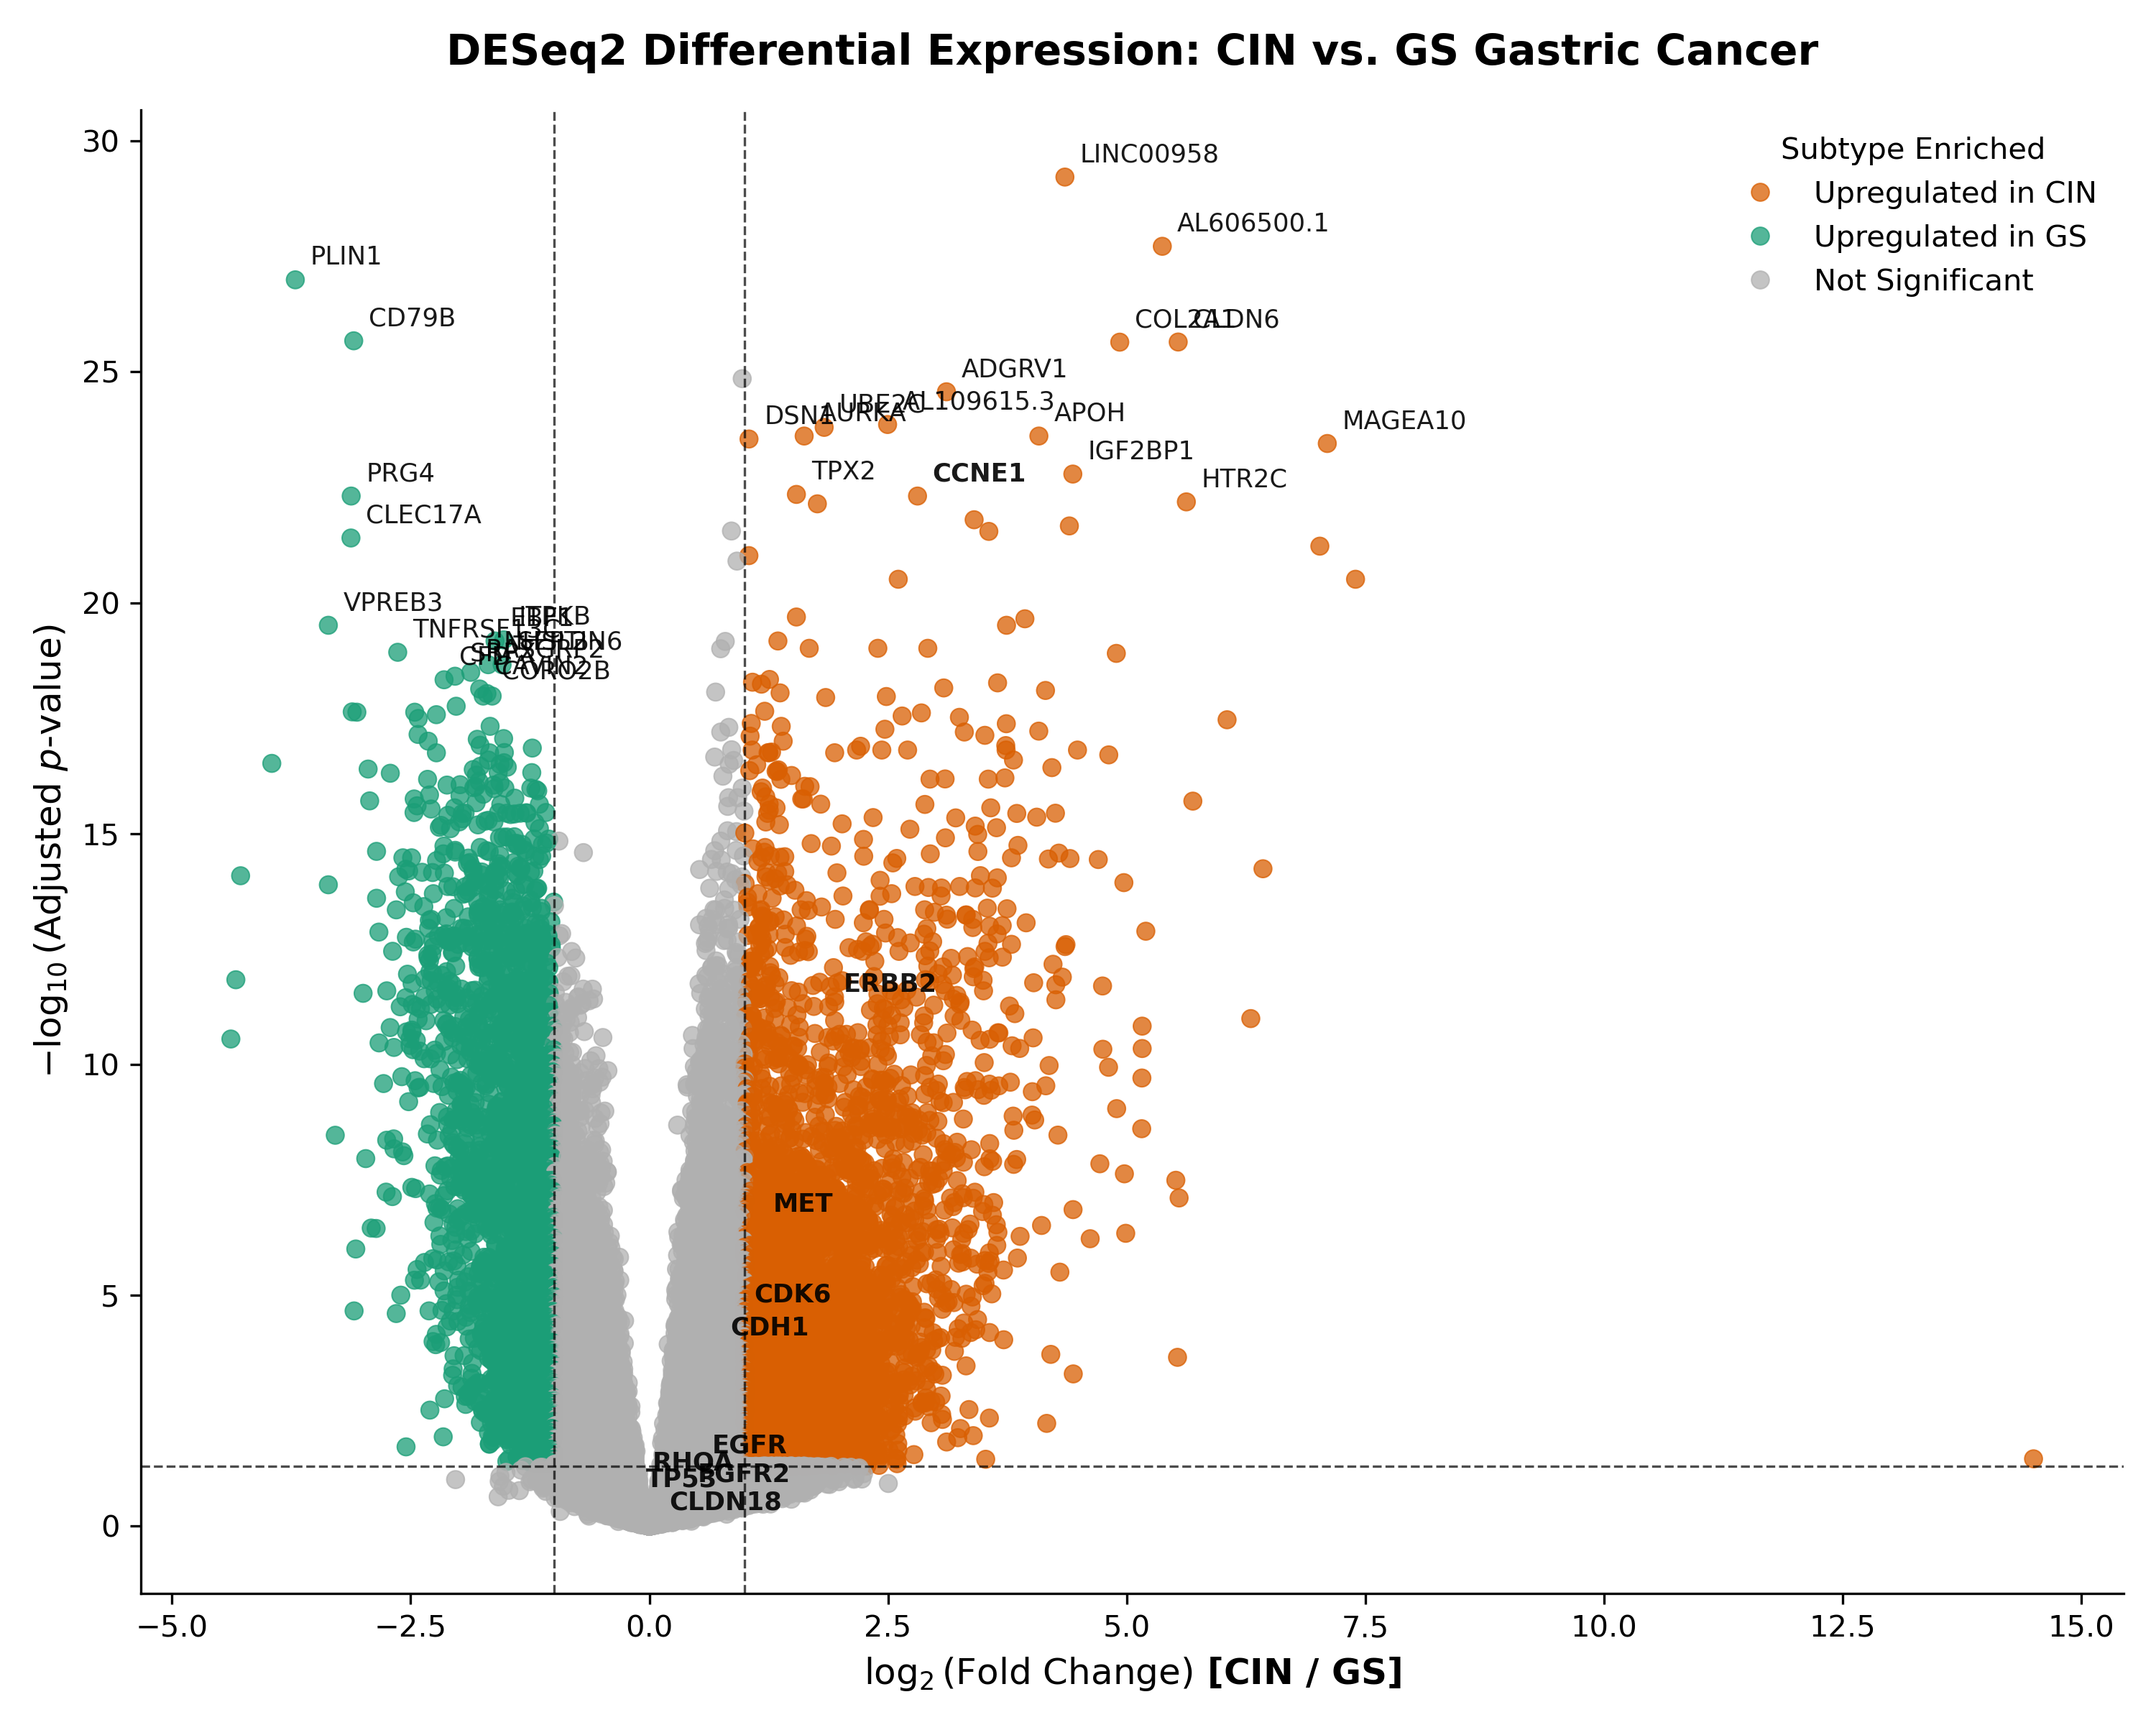

In [4]:
volcano_fig = os.path.join(FIGURES_DIR, "volcano_dge_deseq2.png")
if os.path.exists(volcano_fig):
    display(Image(filename=volcano_fig))


### 4. Gene Set Enrichment Analysis (GSEA - MSigDB Hallmark)

In [5]:
gsea_path = os.path.join(RESULTS_DIR, "gsea_hallmark_results.csv")
gsea_df = pd.read_csv(gsea_path)

print("Top Enriched MSigDB Hallmark Pathways:")
display(gsea_df.head(15)[["Term", "NES", "NOM p-val", "FDR q-val"]])


Top Enriched MSigDB Hallmark Pathways:


,Term,NES,NOM p-val,FDR q-val
0,E2F Targets,3.317506,0.0,0.0
1,Epithelial Mesenchymal Transition,-3.182385,0.0,0.0
2,Myogenesis,-3.003022,0.0,0.0
3,Myc Targets V1,2.949707,0.0,0.0
4,G2-M Checkpoint,2.942946,0.0,0.0
5,UV Response Dn,-2.775642,0.0,0.0
6,Allograft Rejection,-2.640145,0.0,0.0
7,Myc Targets V2,2.549357,0.0,0.0
8,Inflammatory Response,-2.446035,0.0,0.0
9,mTORC1 Signaling,2.445459,0.0,0.0


#### GSEA Hallmark Pathways Barplot

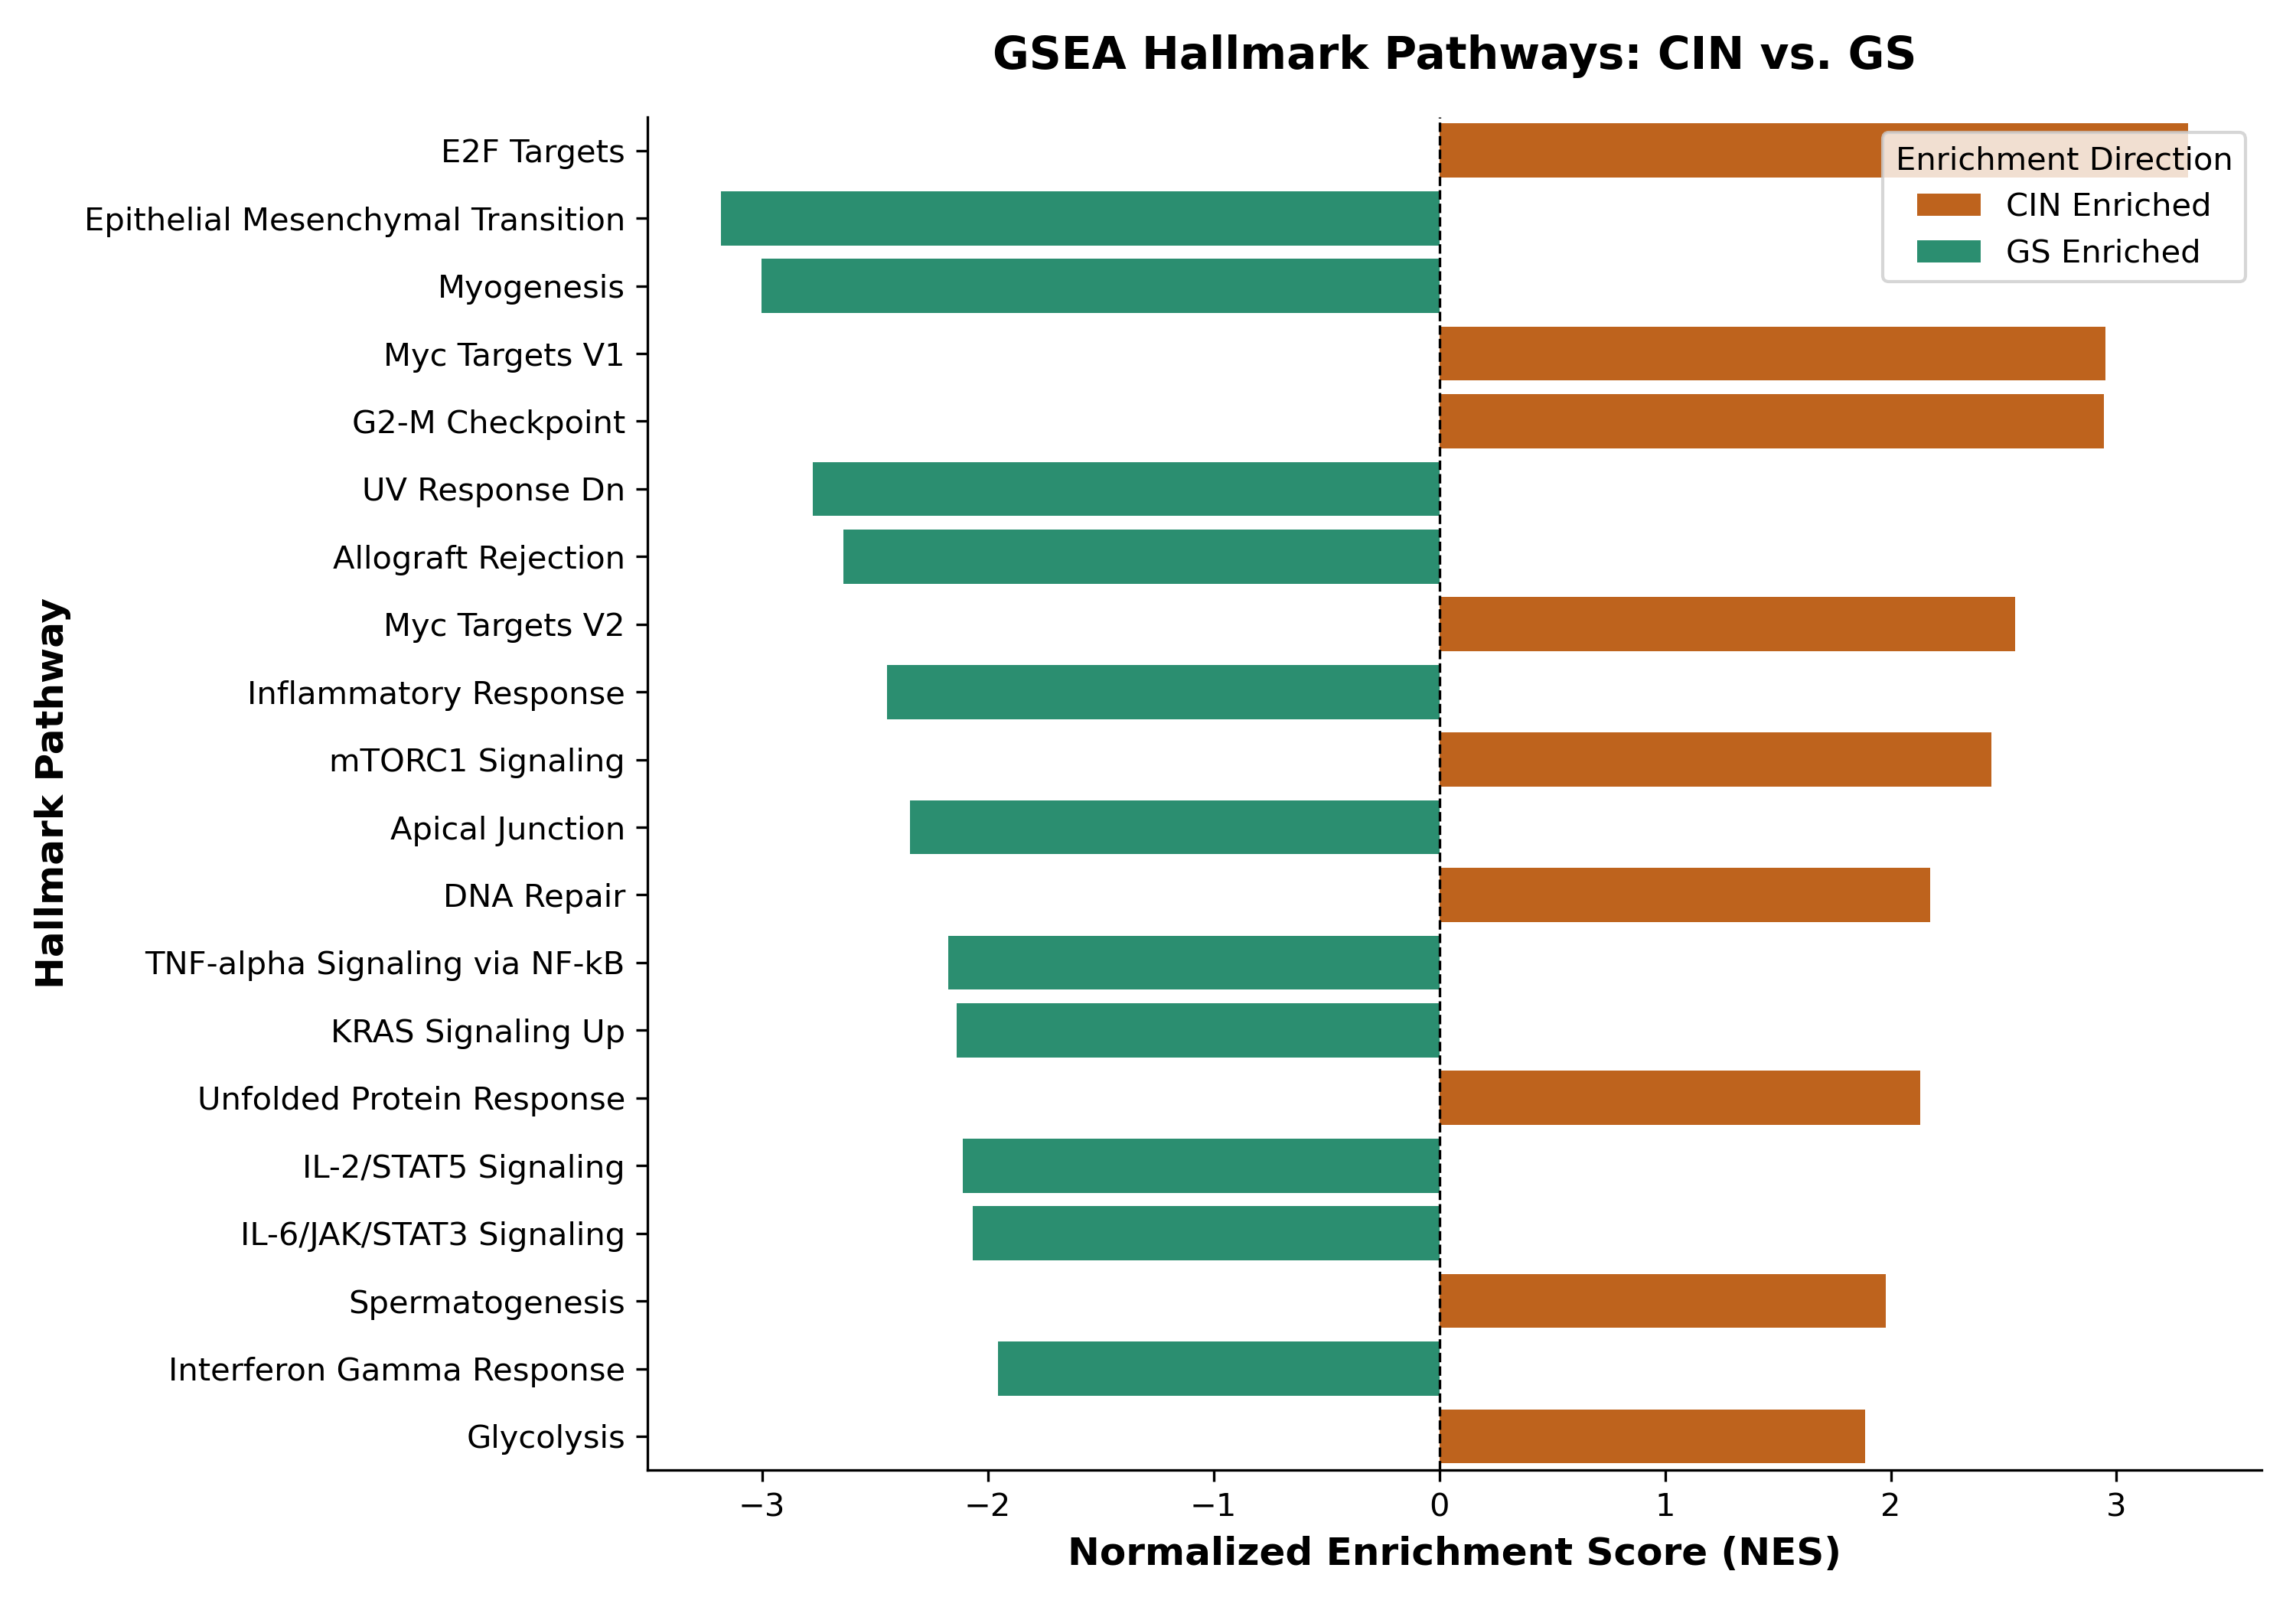

In [6]:
gsea_fig = os.path.join(FIGURES_DIR, "gsea_hallmark_enr.png")
if os.path.exists(gsea_fig):
    display(Image(filename=gsea_fig))


### 5. Transcription Factor Regulatory Activity Scoring (decoupleR + DoRothEA)

In [7]:
tf_acts_path = os.path.join(RESULTS_DIR, "tf_activity_scores.csv")
diff_tf_path = os.path.join(RESULTS_DIR, "differential_tf_activity_gs_vs_cin.csv")

tf_acts = pd.read_csv(tf_acts_path, index_col=0)
diff_tf = pd.read_csv(diff_tf_path)

print(f"Sample-wise TF Activity Matrix shape: {tf_acts.shape} (samples x TFs).")
print("\nTop 10 Most Active TFs in CIN Tumors:")
display(diff_tf[diff_tf["diff_CIN_vs_GS"] > 0].head(10)[["TF", "mean_CIN", "mean_GS", "diff_CIN_vs_GS", "pvalue", "padj"]])

print("\nTop 10 Most Active TFs in GS Tumors:")
display(diff_tf[diff_tf["diff_CIN_vs_GS"] < 0].head(10)[["TF", "mean_CIN", "mean_GS", "diff_CIN_vs_GS", "pvalue", "padj"]])


Sample-wise TF Activity Matrix shape: (190, 298) (samples x TFs).

Top 10 Most Active TFs in CIN Tumors:


,TF,mean_CIN,mean_GS,diff_CIN_vs_GS,pvalue,padj
1,NR2C2,17.840603,16.993142,0.847461,4.616493e-17,6.878575e-15
2,E2F3,6.515438,5.232363,1.283076,1.156955e-14,1.149242e-12
9,E2F4,42.285664,39.719666,2.565998,1.616361e-12,4.816756e-11
10,TFDP1,15.903777,14.551683,1.352094,2.412286e-12,6.535102e-11
11,E2F2,7.821329,6.399162,1.422167,2.931290e-12,7.279370e-11
27,THAP11,18.231883,17.742693,0.489189,9.413998e-11,1.001918e-09
69,ATF6,9.224742,8.852038,0.372704,1.782231e-08,7.587214e-08
70,TGIF2,8.827083,8.456615,0.370469,2.640340e-08,1.108199e-07
92,SREBF2,13.418551,12.319988,1.098563,4.224103e-07,1.353530e-06
98,MYC,33.775179,32.825784,0.949394,9.864659e-07,2.969362e-06



Top 10 Most Active TFs in GS Tumors:


,TF,mean_CIN,mean_GS,diff_CIN_vs_GS,pvalue,padj
0,GLI1,1.804980,2.673552,-0.868572,9.195403e-19,2.740230e-16
3,TP53,24.826118,26.578404,-1.752286,2.441544e-14,1.818950e-12
4,MEF2C,11.035772,12.592678,-1.556906,1.326567e-13,7.906337e-12
5,STAT5B,12.700510,14.009531,-1.309021,3.341147e-13,1.659437e-11
6,RUNX1,29.733103,31.973608,-2.240505,8.141965e-13,3.466151e-11
7,ZHX2,7.252283,7.728990,-0.476706,1.527121e-12,4.816756e-11
8,EBF1,14.844790,16.415122,-1.570333,1.541092e-12,4.816756e-11
12,MEF2A,17.755079,19.831540,-2.076461,3.352690e-12,7.685397e-11
13,IRF4,11.565018,13.371125,-1.806107,4.340959e-12,9.240041e-11
14,TP73,7.852238,8.423541,-0.571304,5.989224e-12,1.189859e-10


#### TF Activity Visualizations

TF Regulatory Activity Clustered Heatmap:


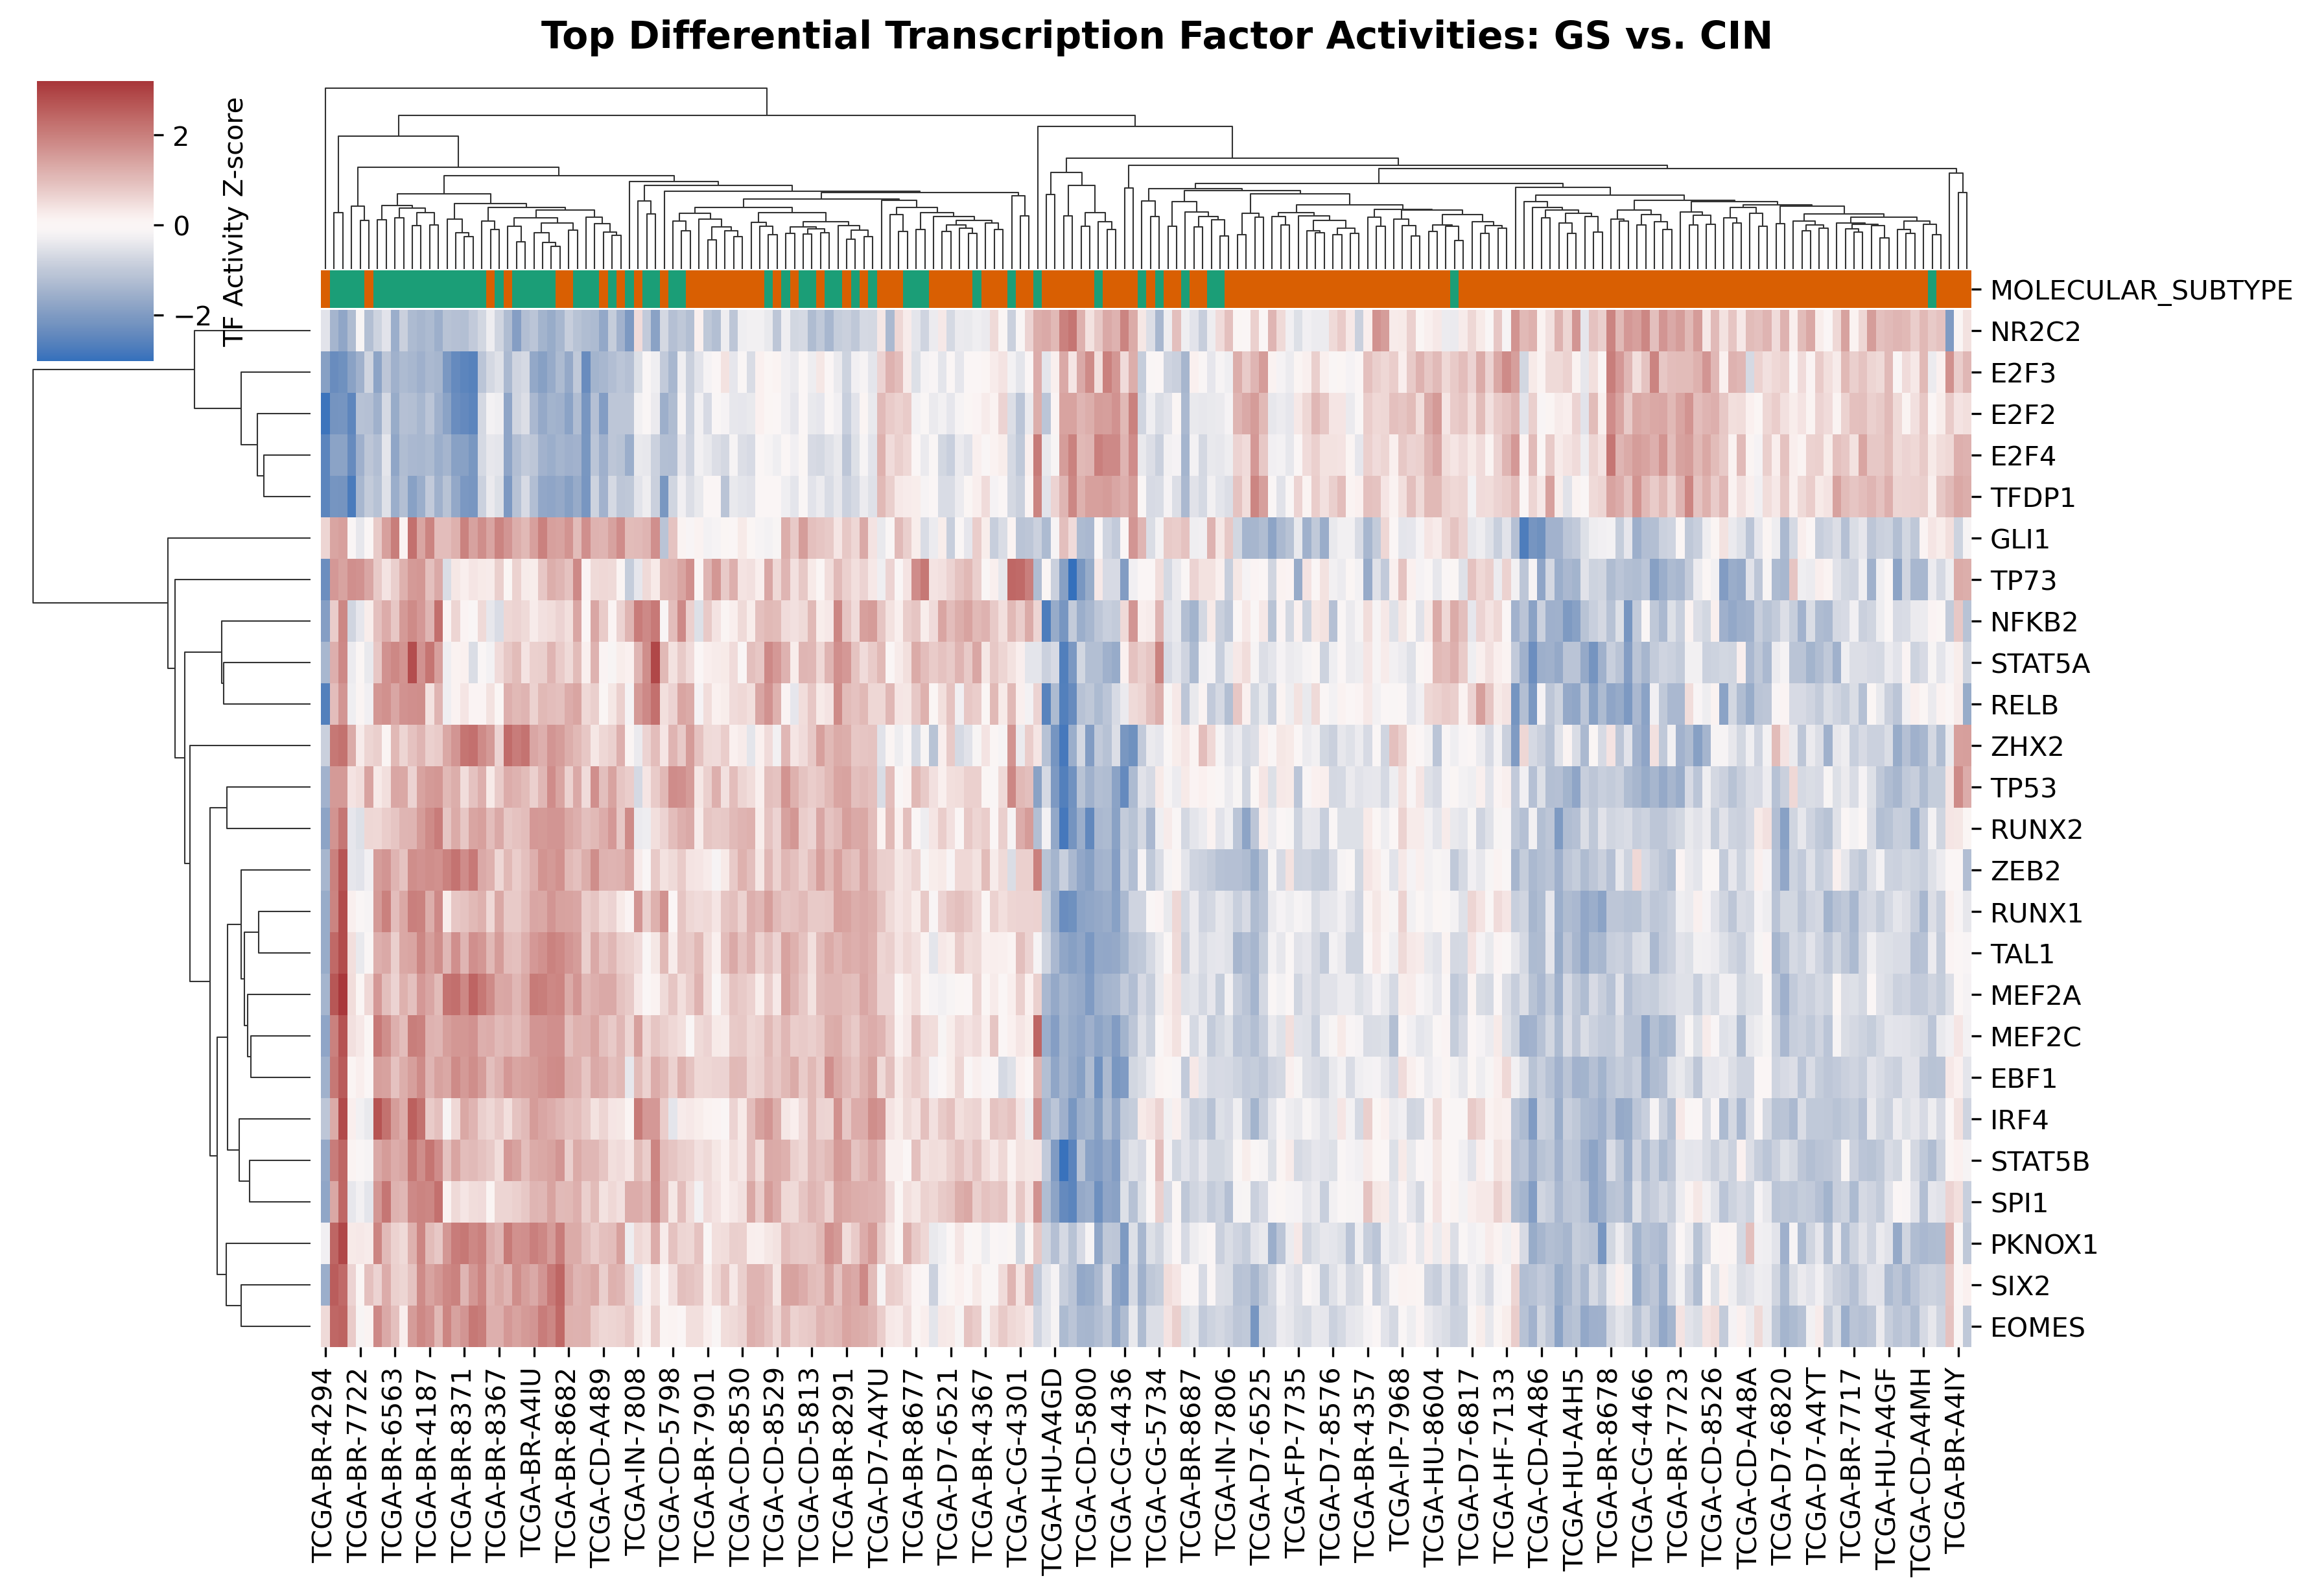

Differential TF Regulatory Activity Volcano Plot:


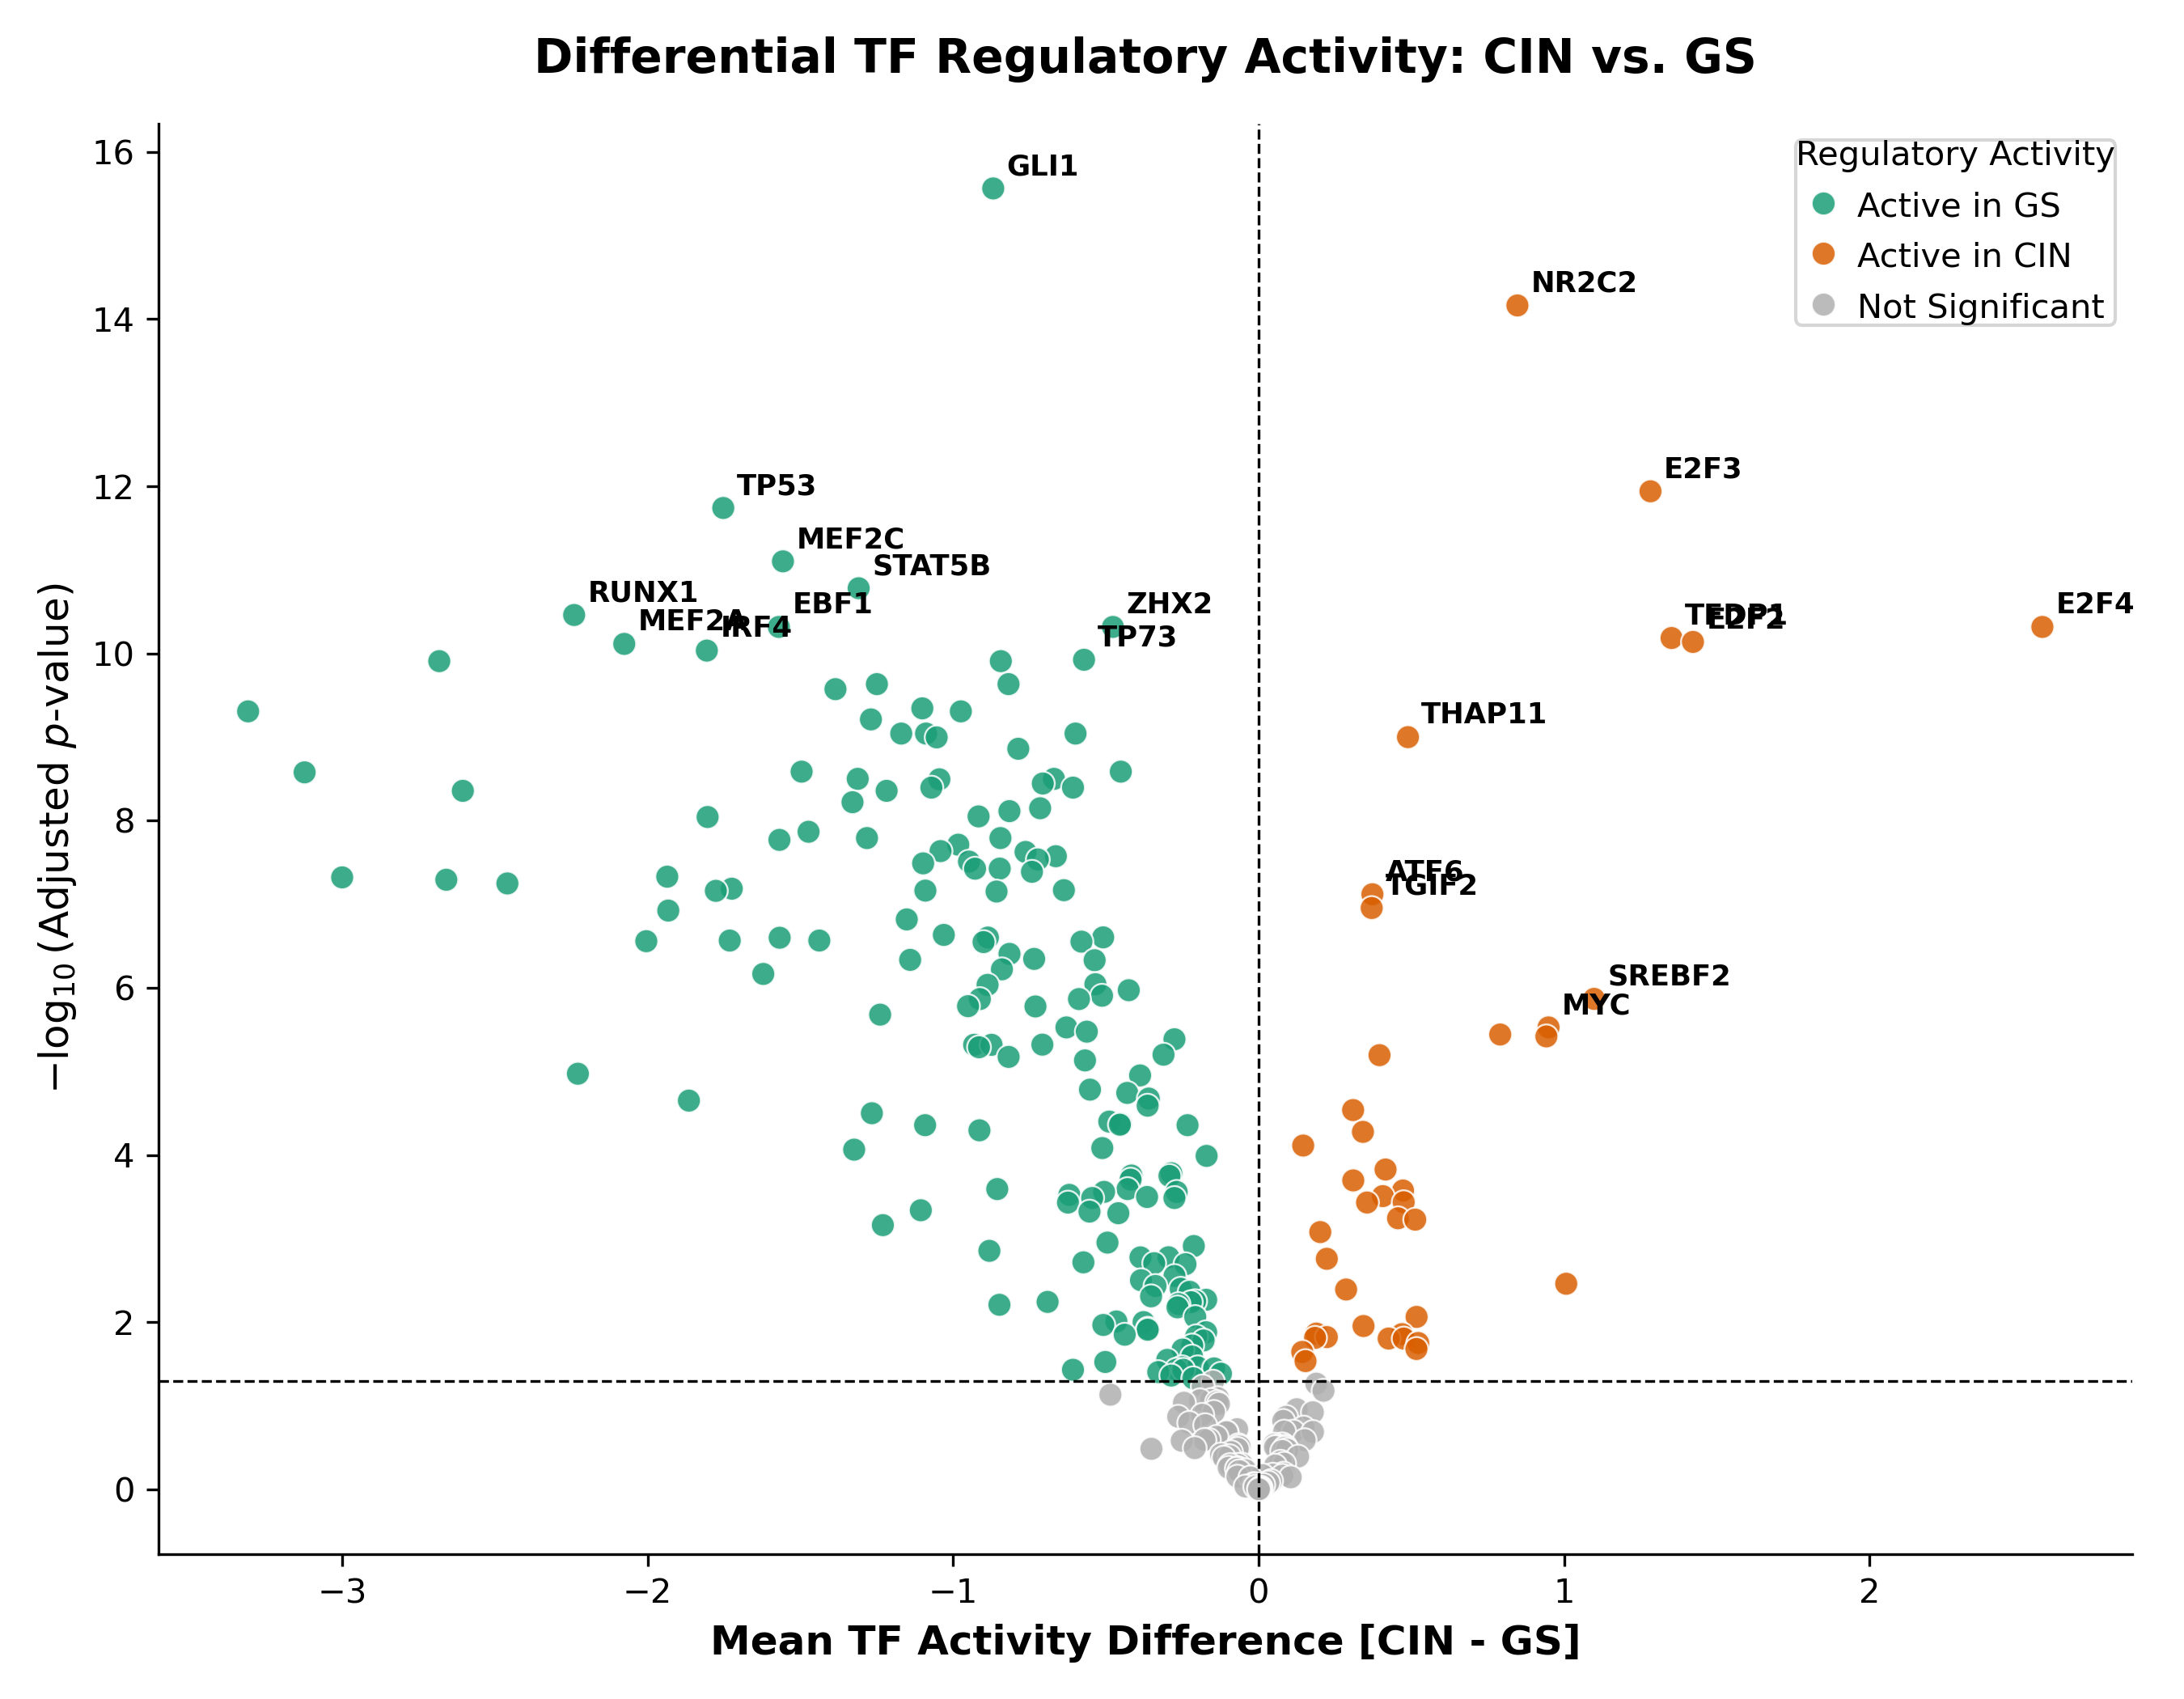

In [8]:
tf_heatmap = os.path.join(FIGURES_DIR, "tf_activity_heatmap.png")
tf_volcano = os.path.join(FIGURES_DIR, "tf_activity_volcano.png")

if os.path.exists(tf_heatmap):
    print("TF Regulatory Activity Clustered Heatmap:")
    display(Image(filename=tf_heatmap))

if os.path.exists(tf_volcano):
    print("Differential TF Regulatory Activity Volcano Plot:")
    display(Image(filename=tf_volcano))


### 6. Copy Number Alterations (CNV) & Fraction Genome Altered (FGA)

FGA Burden Dataset shape: (189, 4) (samples x metrics).

Mean FGA by Subtype:
MOLECULAR_SUBTYPE
CIN    0.344974
GS     0.038230

Top Focal Driver Alteration Frequencies (% High Amplification +2):


,Gene,CIN_Amp_Pct,GS_Amp_Pct,CIN_Del_Pct,GS_Del_Pct,Pval_Amp
0,CCNE1,19.117647,1.886792,0.735294,0.0,0.001089
1,ERBB2,22.058824,3.773585,0.000000,0.0,0.002030
2,CDK6,13.970588,0.000000,0.735294,0.0,0.002119
3,MET,8.088235,0.000000,0.000000,0.0,0.036038
4,MYC,18.382353,7.547170,0.000000,0.0,0.073775
5,KRAS,12.500000,3.773585,0.000000,0.0,0.104444
6,EGFR,9.558824,3.773585,0.735294,0.0,0.241040
7,CLDN18,2.205882,0.000000,0.000000,0.0,0.560652
8,FGFR2,7.352941,7.547170,0.000000,0.0,1.000000
9,TP53,0.000000,0.000000,0.735294,0.0,1.000000


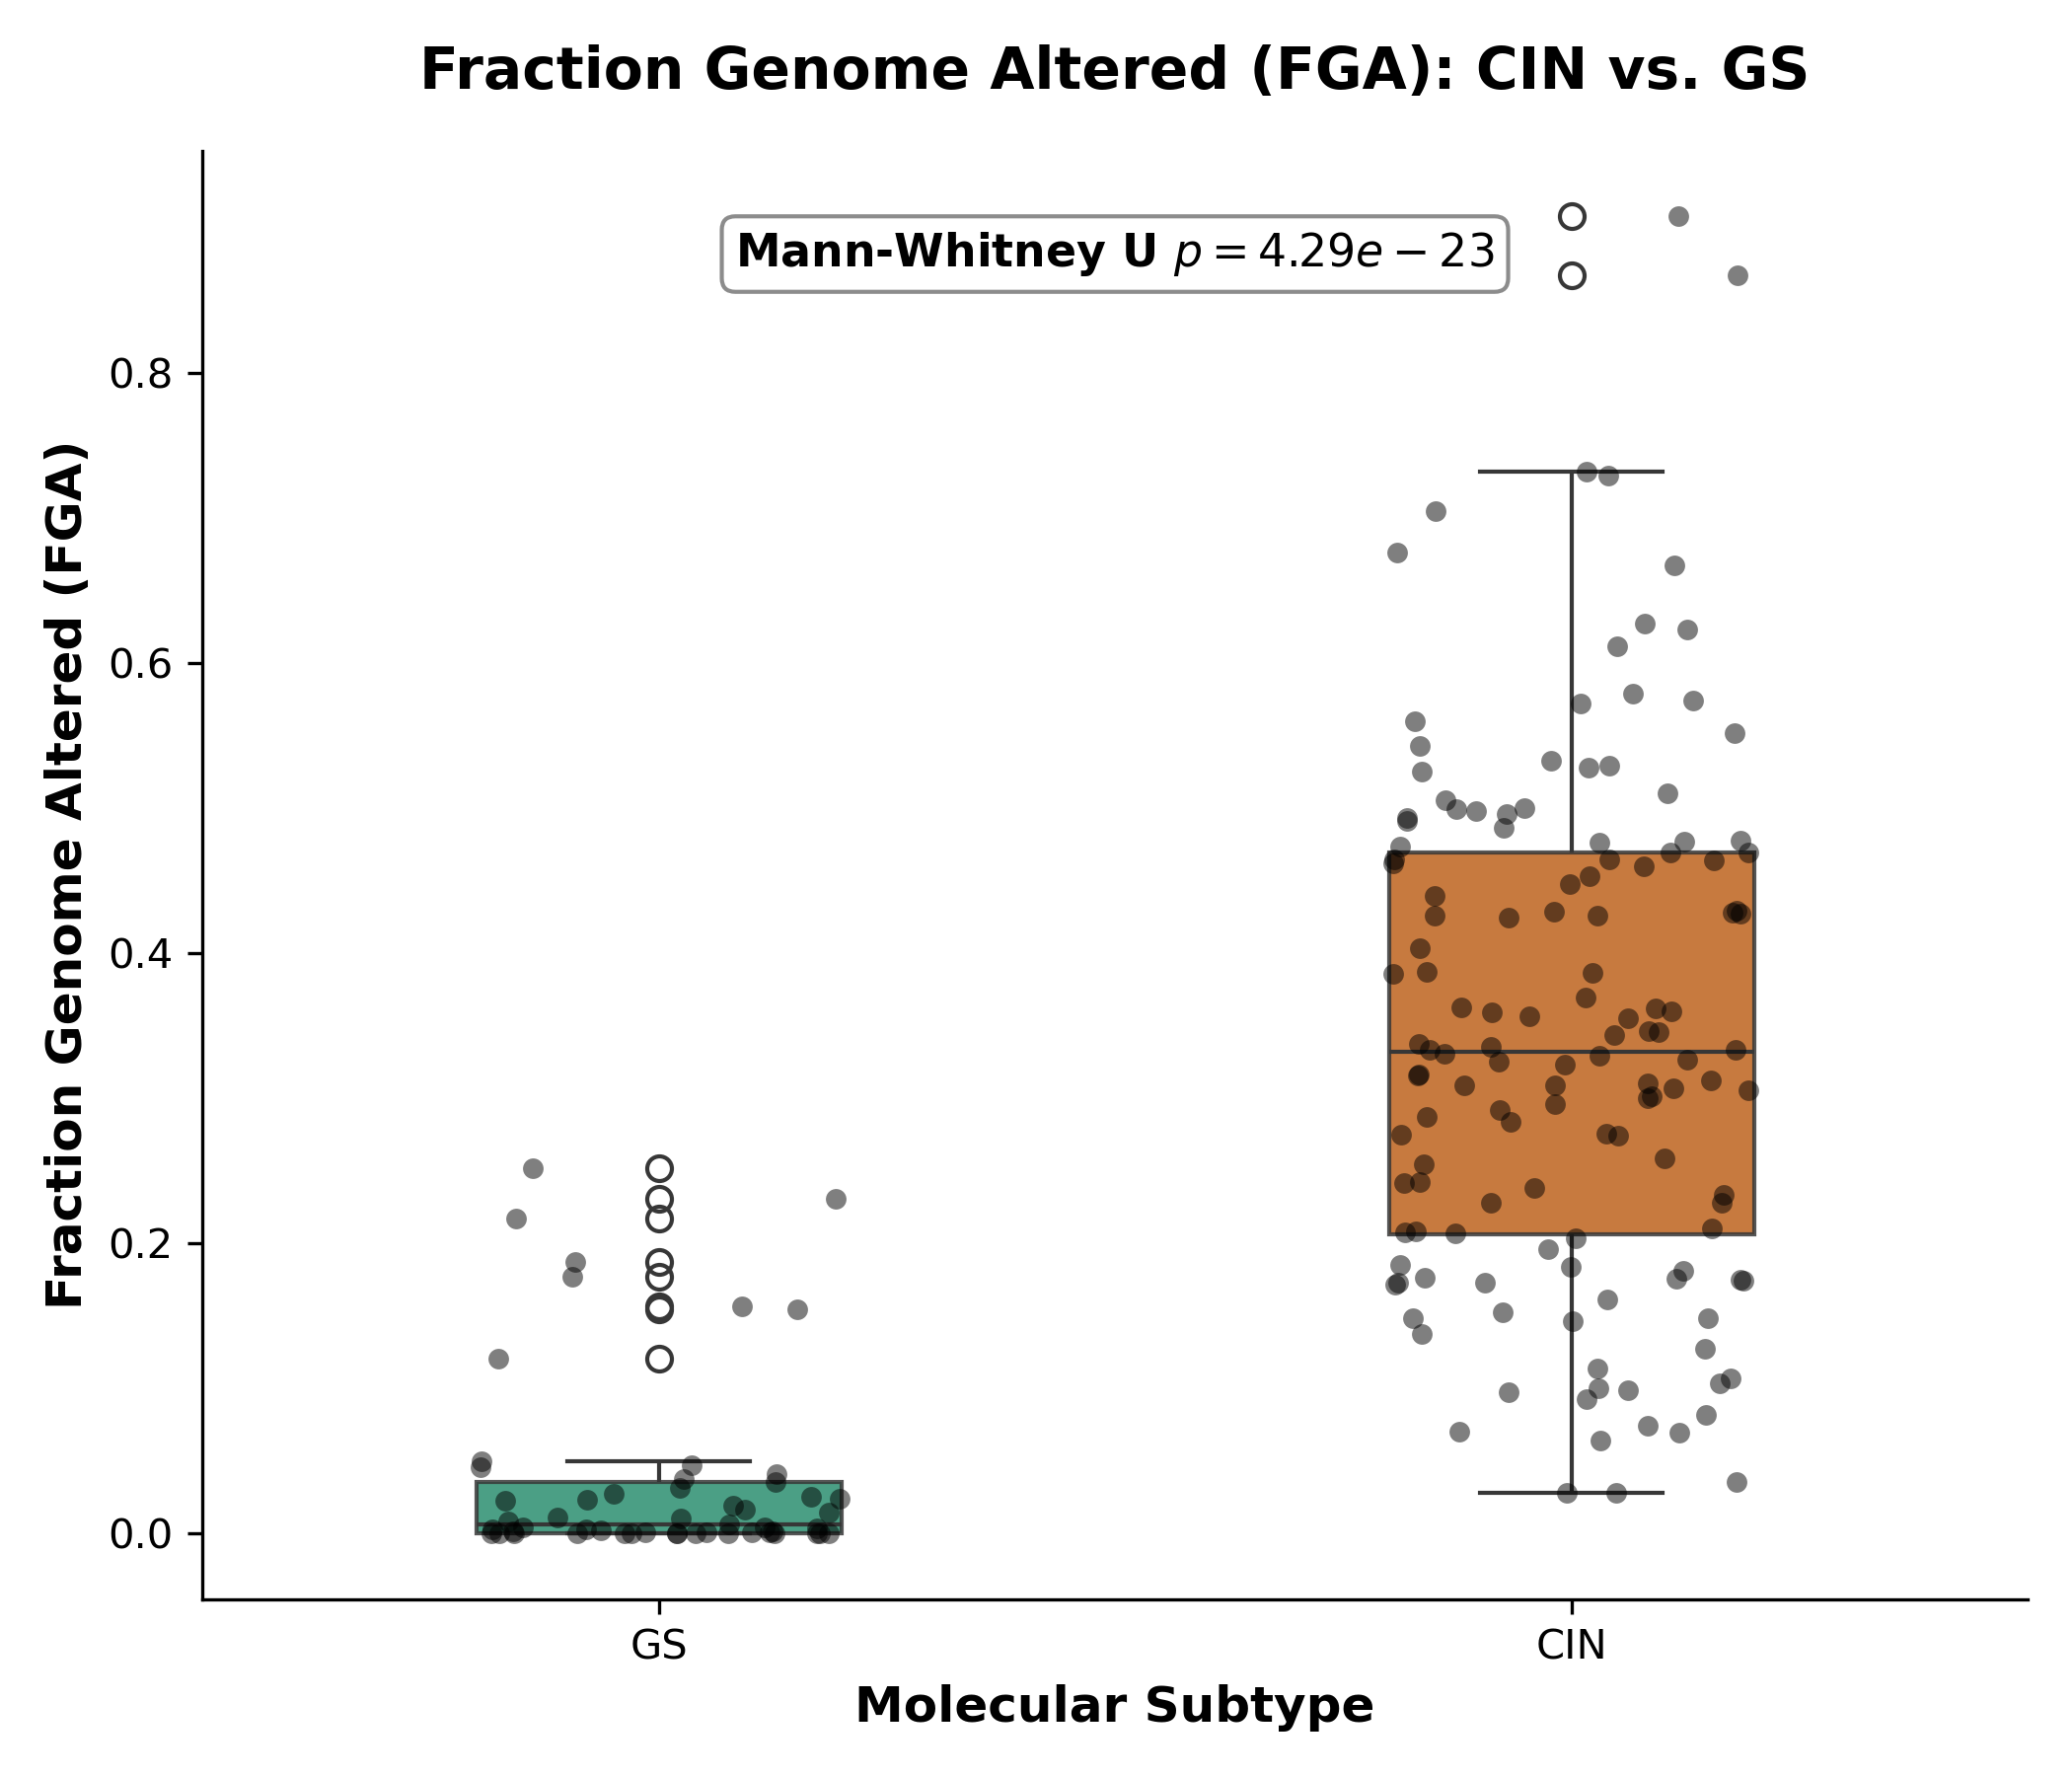

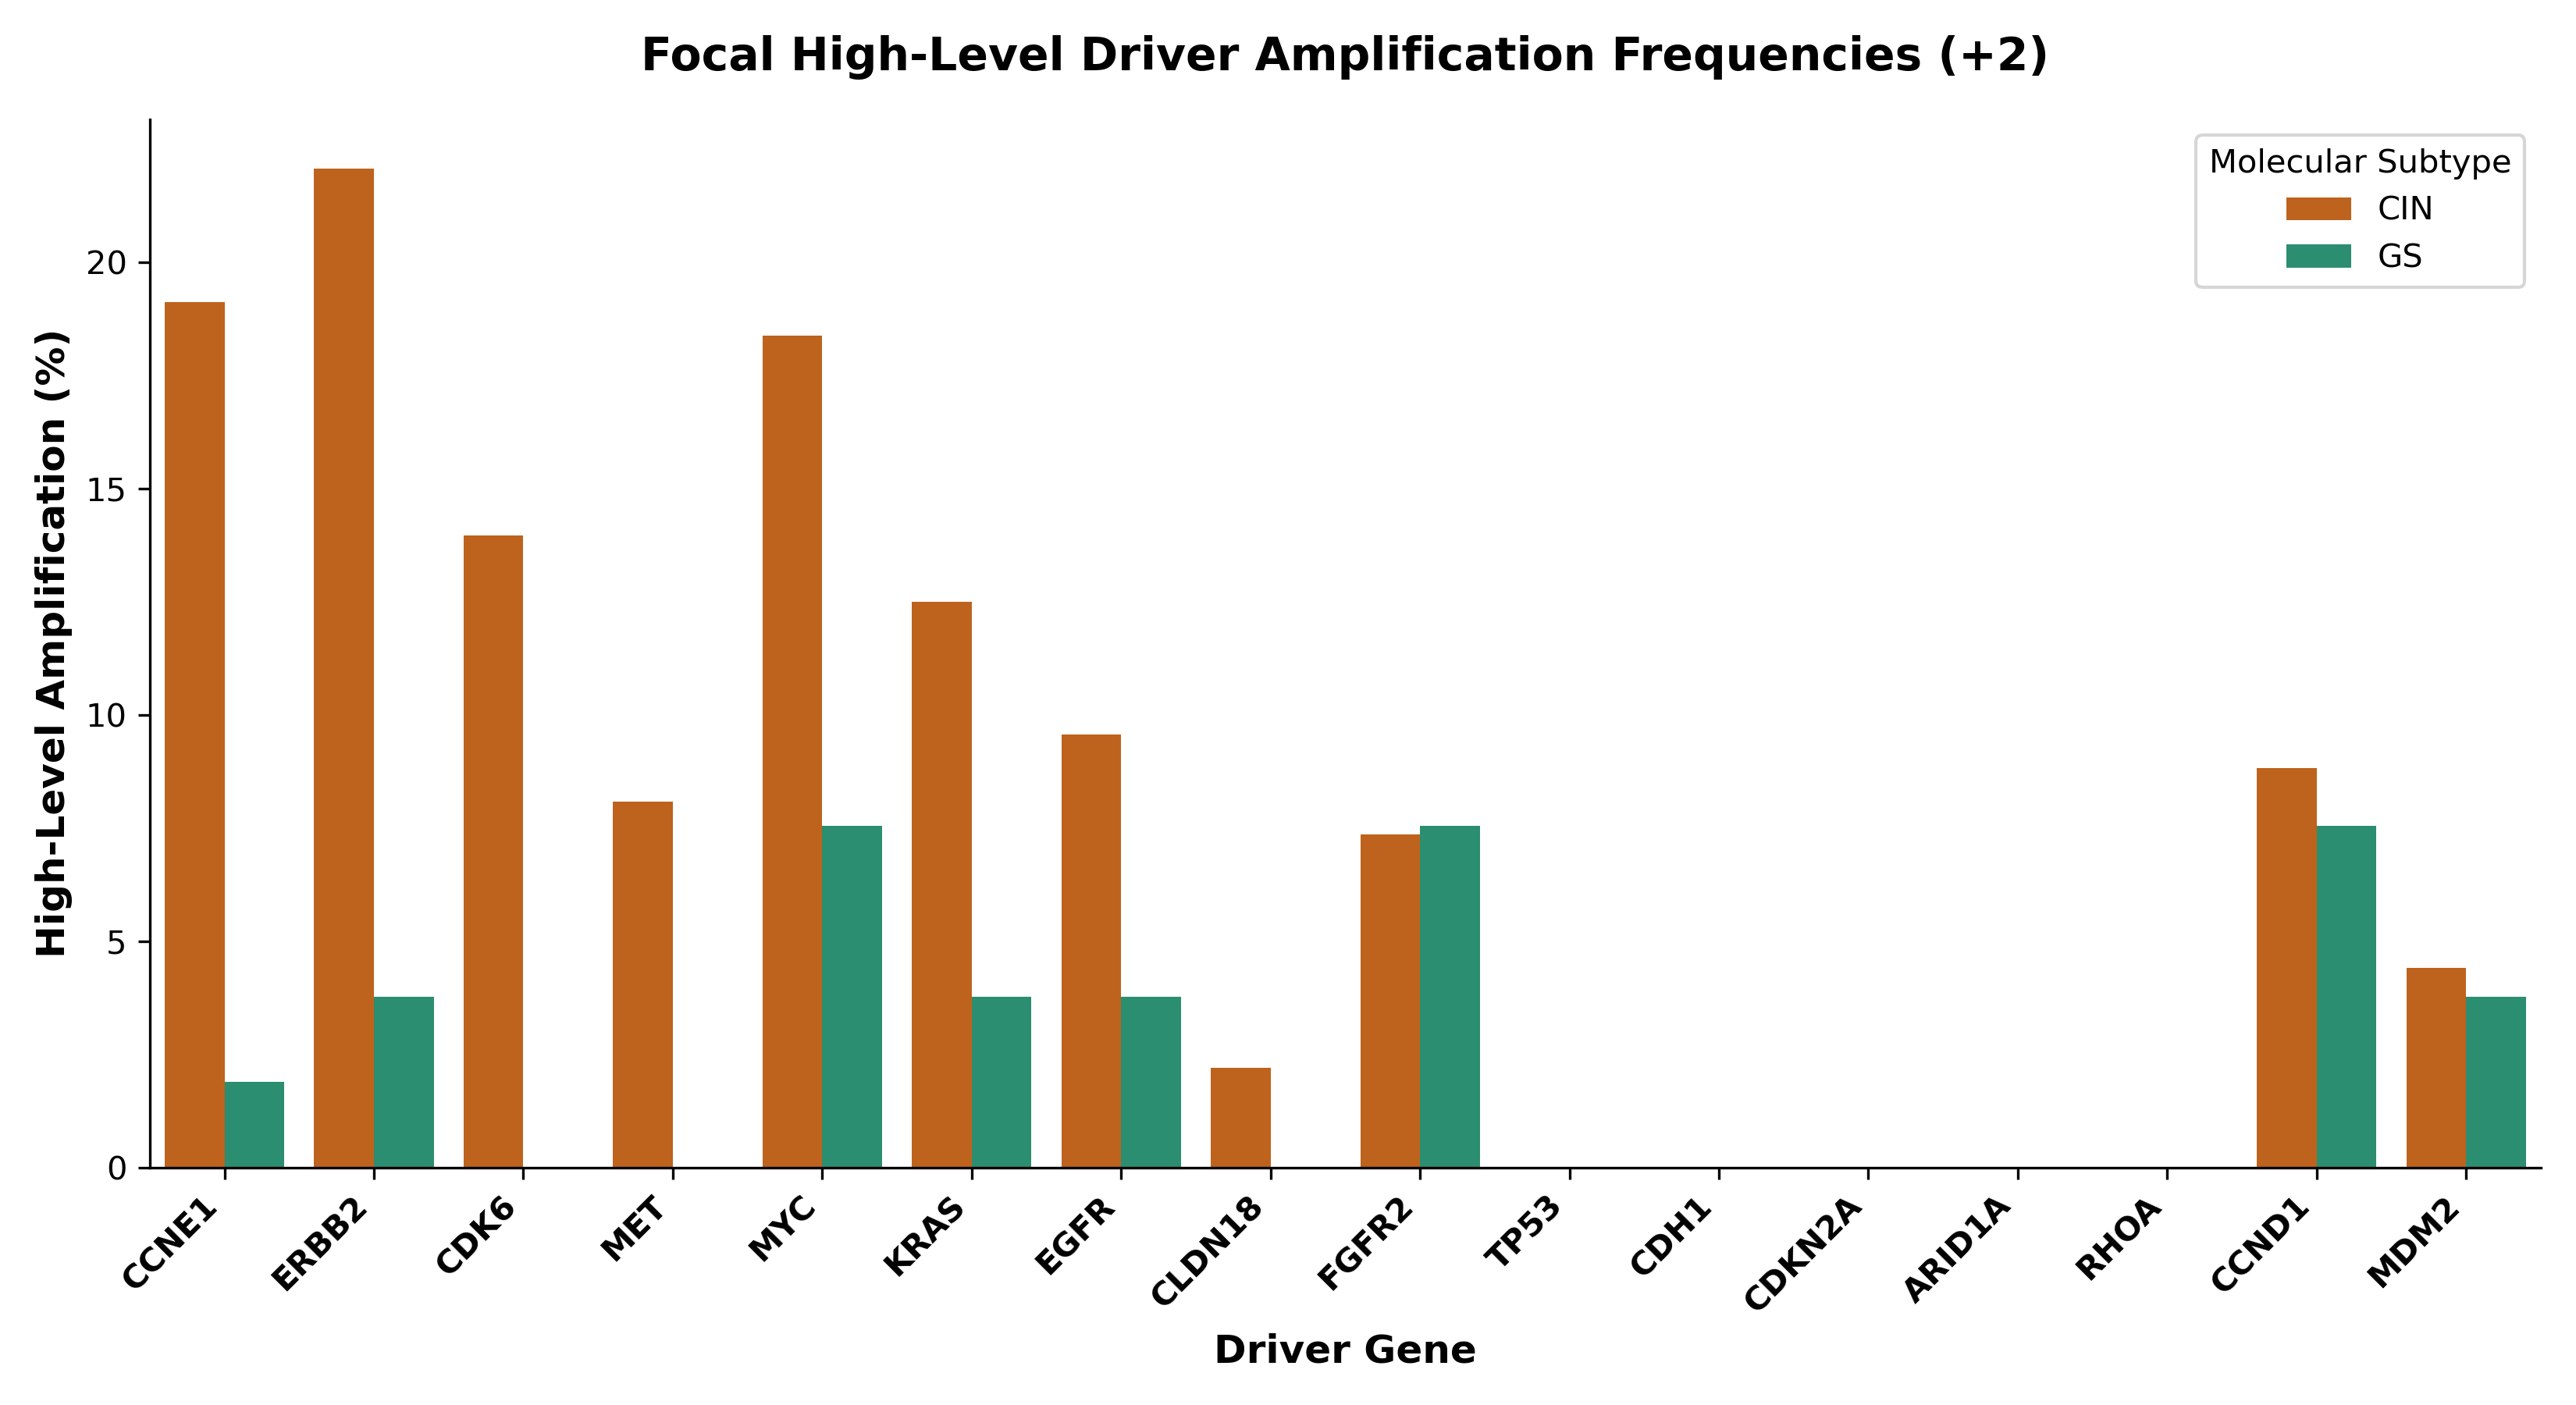

In [9]:
fga_path = os.path.join(RESULTS_DIR, "cnv_fga_burden.csv")
focal_path = os.path.join(RESULTS_DIR, "cnv_focal_alterations.csv")

fga_df = pd.read_csv(fga_path, index_col=0)
focal_df = pd.read_csv(focal_path)

print(f"FGA Burden Dataset shape: {fga_df.shape} (samples x metrics).")
print("\nMean FGA by Subtype:")
print(fga_df.groupby("MOLECULAR_SUBTYPE")["FGA"].mean().to_string())

print("\nTop Focal Driver Alteration Frequencies (% High Amplification +2):")
display(focal_df.head(10))

fga_fig = os.path.join(FIGURES_DIR, "cnv_fga_distribution.png")
driver_fig = os.path.join(FIGURES_DIR, "cnv_alteration_frequencies.png")

if os.path.exists(fga_fig):
    display(Image(filename=fga_fig))
if os.path.exists(driver_fig):
    display(Image(filename=driver_fig))


### 7. Somatic Mutational Signatures (COSMIC SBS 96-Trinucleotide Deconvolution)

Mutational Signature Exposures shape: (190, 5) (samples x signatures).

Differential Mutational Signature Exposures (CIN vs GS):


,Signature,mean_CIN,mean_GS,diff_CIN_vs_GS,stat,pvalue
0,SBS2_13_APOBEC,0.216259,0.106686,0.109574,4.286259,0.000038
1,SBS17_Gastric_5FU,0.137574,0.086192,0.051382,2.044562,0.043186
2,SBS3_HRD,0.531561,0.595337,-0.063775,-1.585802,0.116545
3,SBS5_Clock,0.077703,0.096123,-0.018420,-0.947047,0.347310
4,SBS1_Aging,0.029549,0.041588,-0.012039,-0.933120,0.354701


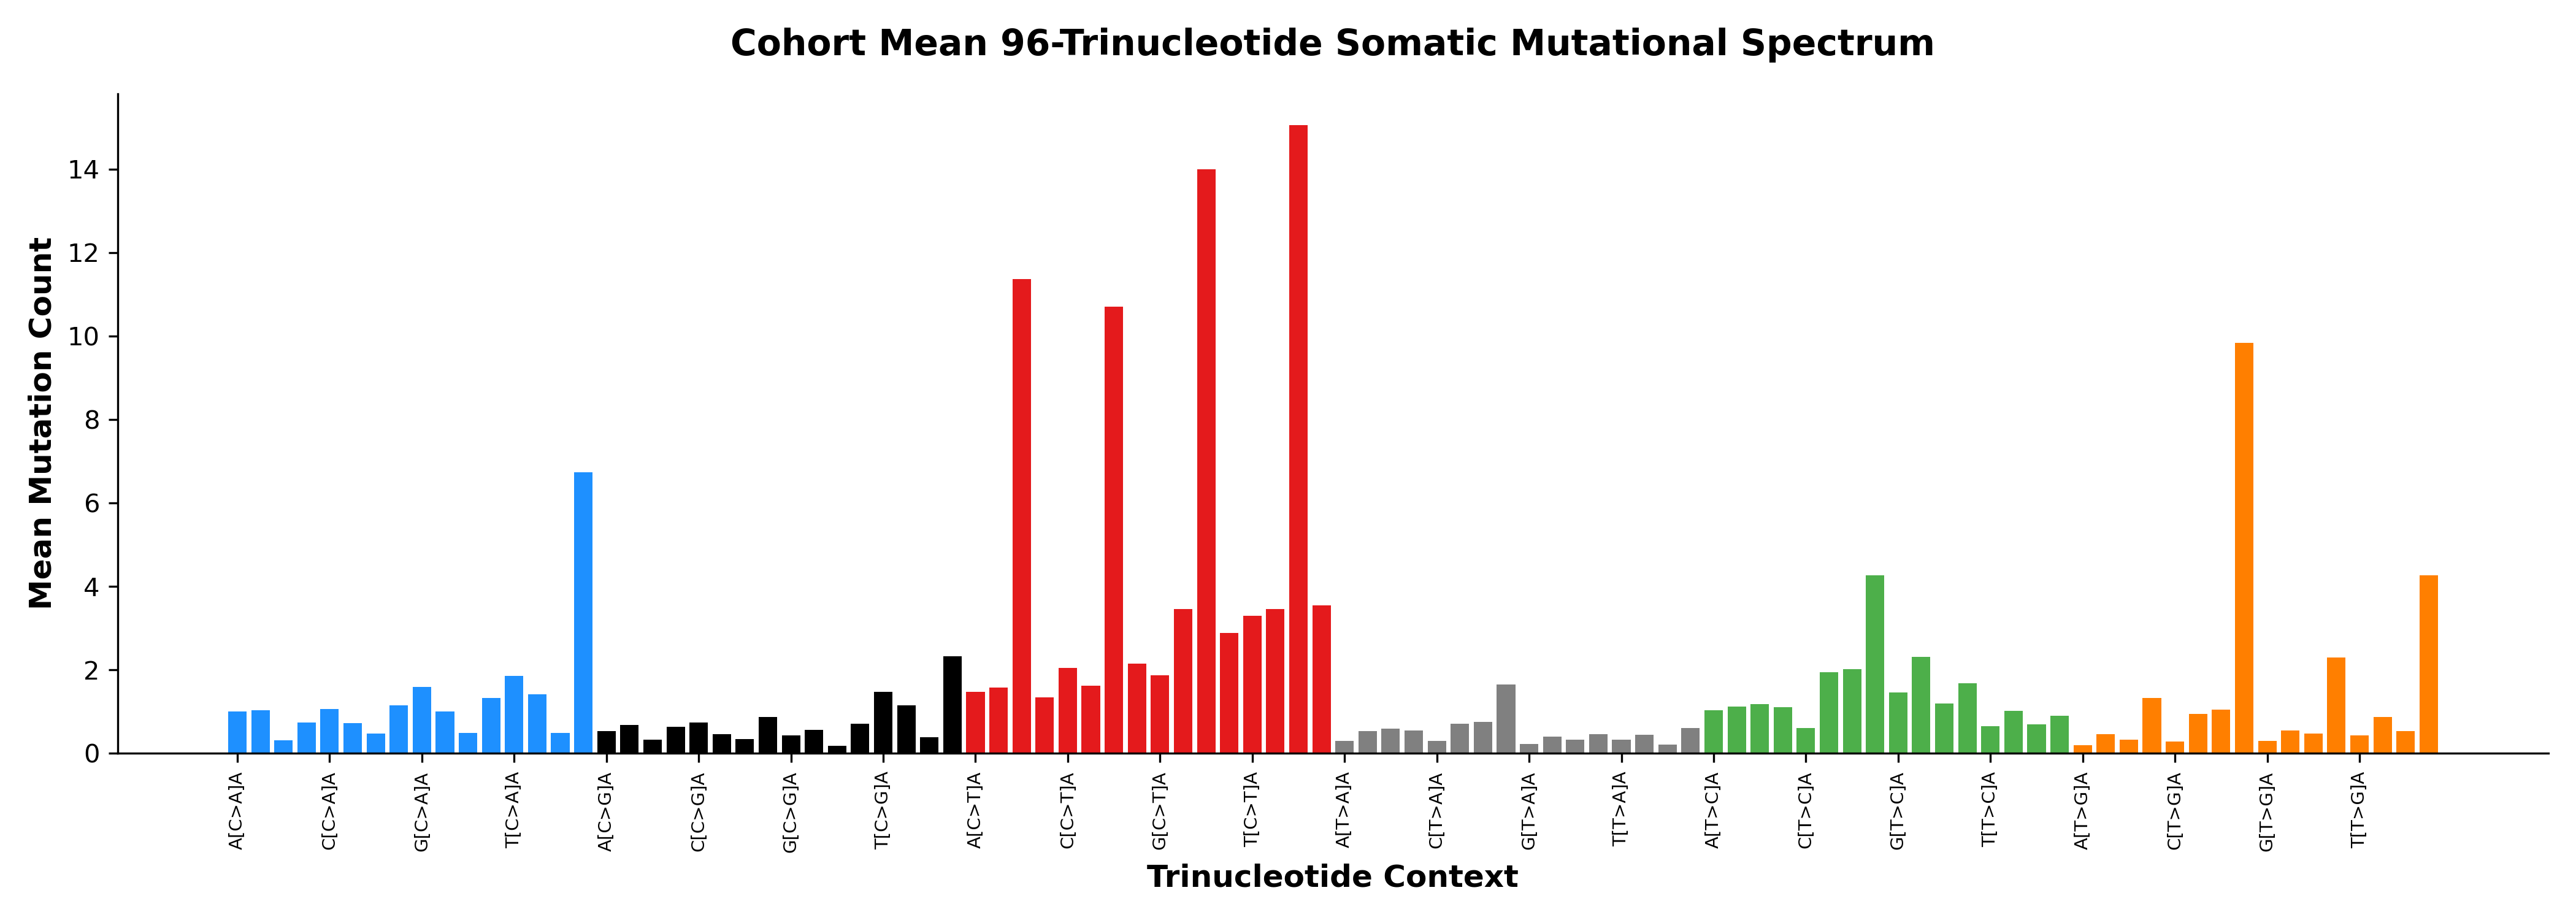

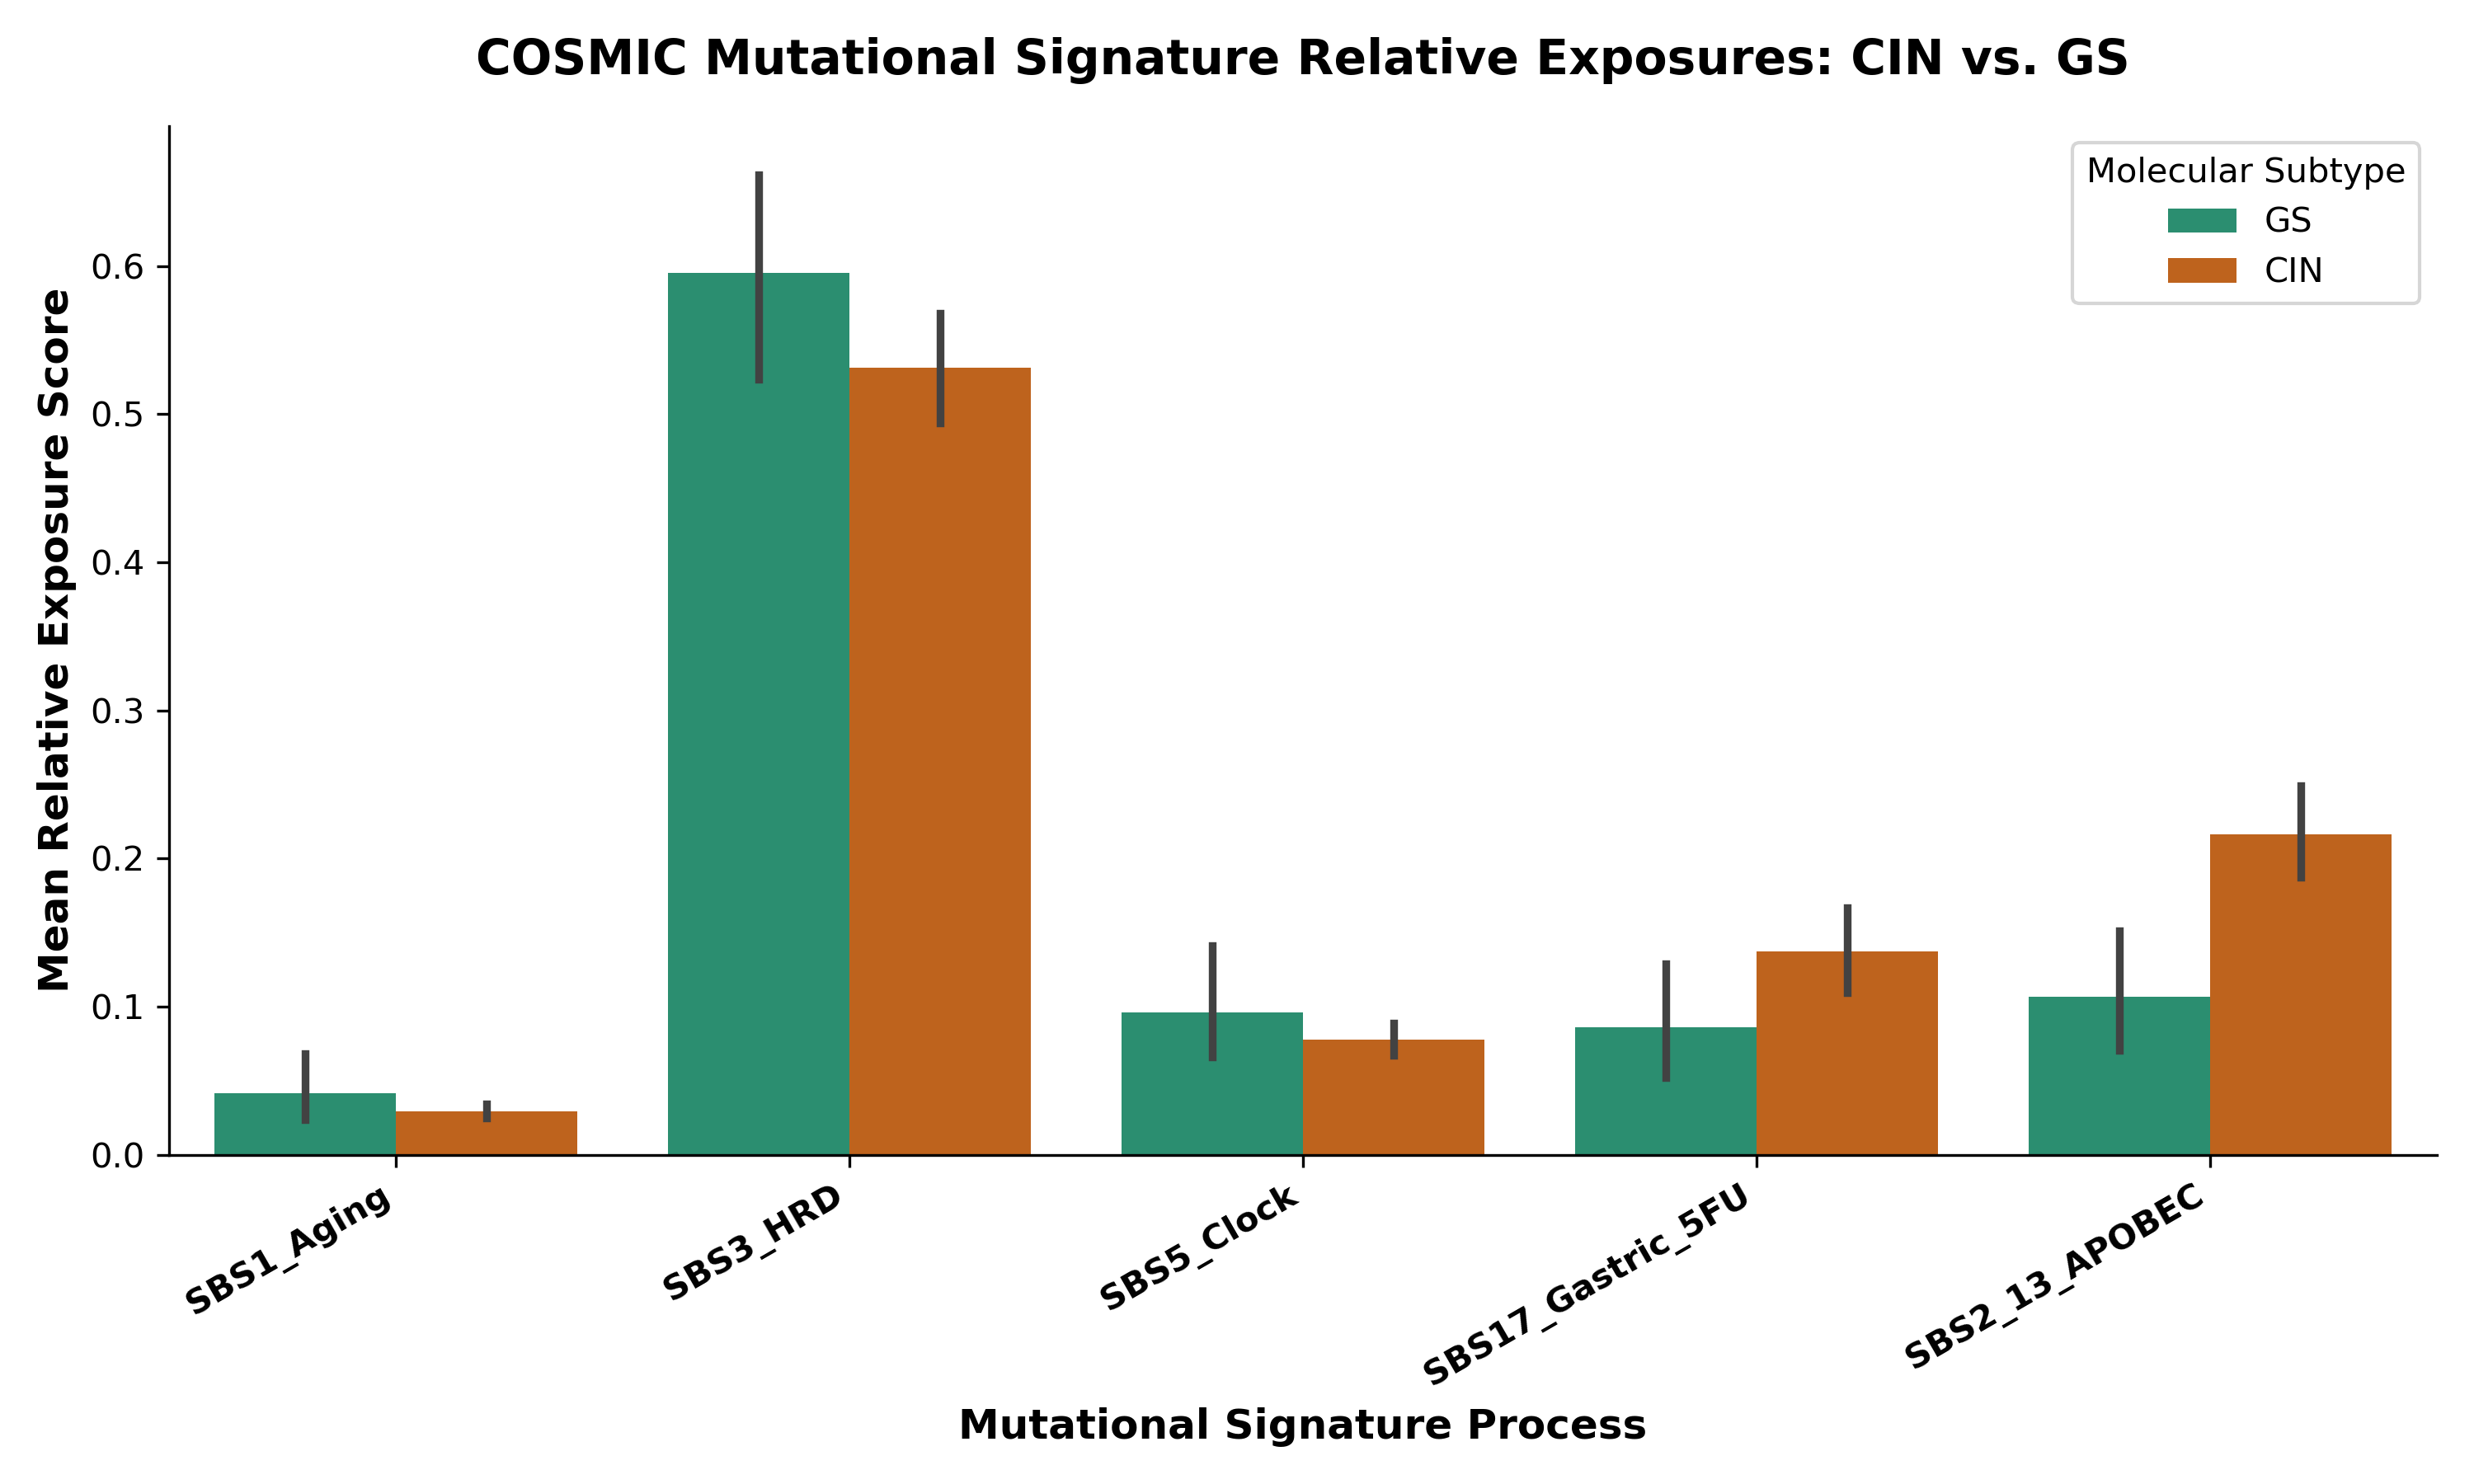

In [10]:
mut_sig_path = os.path.join(RESULTS_DIR, "mutational_signature_activities.csv")
diff_sig_path = os.path.join(RESULTS_DIR, "differential_mutational_signatures.csv")

mut_sig_df = pd.read_csv(mut_sig_path, index_col=0)
diff_sig_df = pd.read_csv(diff_sig_path)

print(f"Mutational Signature Exposures shape: {mut_sig_df.shape} (samples x signatures).")
print("\nDifferential Mutational Signature Exposures (CIN vs GS):")
display(diff_sig_df)

spec_fig = os.path.join(FIGURES_DIR, "mutational_spectrum_96.png")
exp_fig = os.path.join(FIGURES_DIR, "mutational_signature_exposures.png")

if os.path.exists(spec_fig):
    display(Image(filename=spec_fig))
if os.path.exists(exp_fig):
    display(Image(filename=exp_fig))


### 8. Structural Variants & Gene Fusions (data_sv.txt)

Structural Variant Matrix shape: (190, 3) (samples x events).

Structural Variant & Gene Fusion Summary:


,SV_Event,CIN_Count,CIN_Pct,GS_Count,GS_Pct,Odds_Ratio,Fisher_Pval
0,SV_CLDN18_Fusion,2,1.470588,8,14.814815,0.085821,0.000776
1,SV_MYLK_Fusion,7,5.147059,0,0.000000,inf,0.194422
2,SV_CDKN2A_Silenced,13,9.558824,6,11.111111,0.845528,0.790379


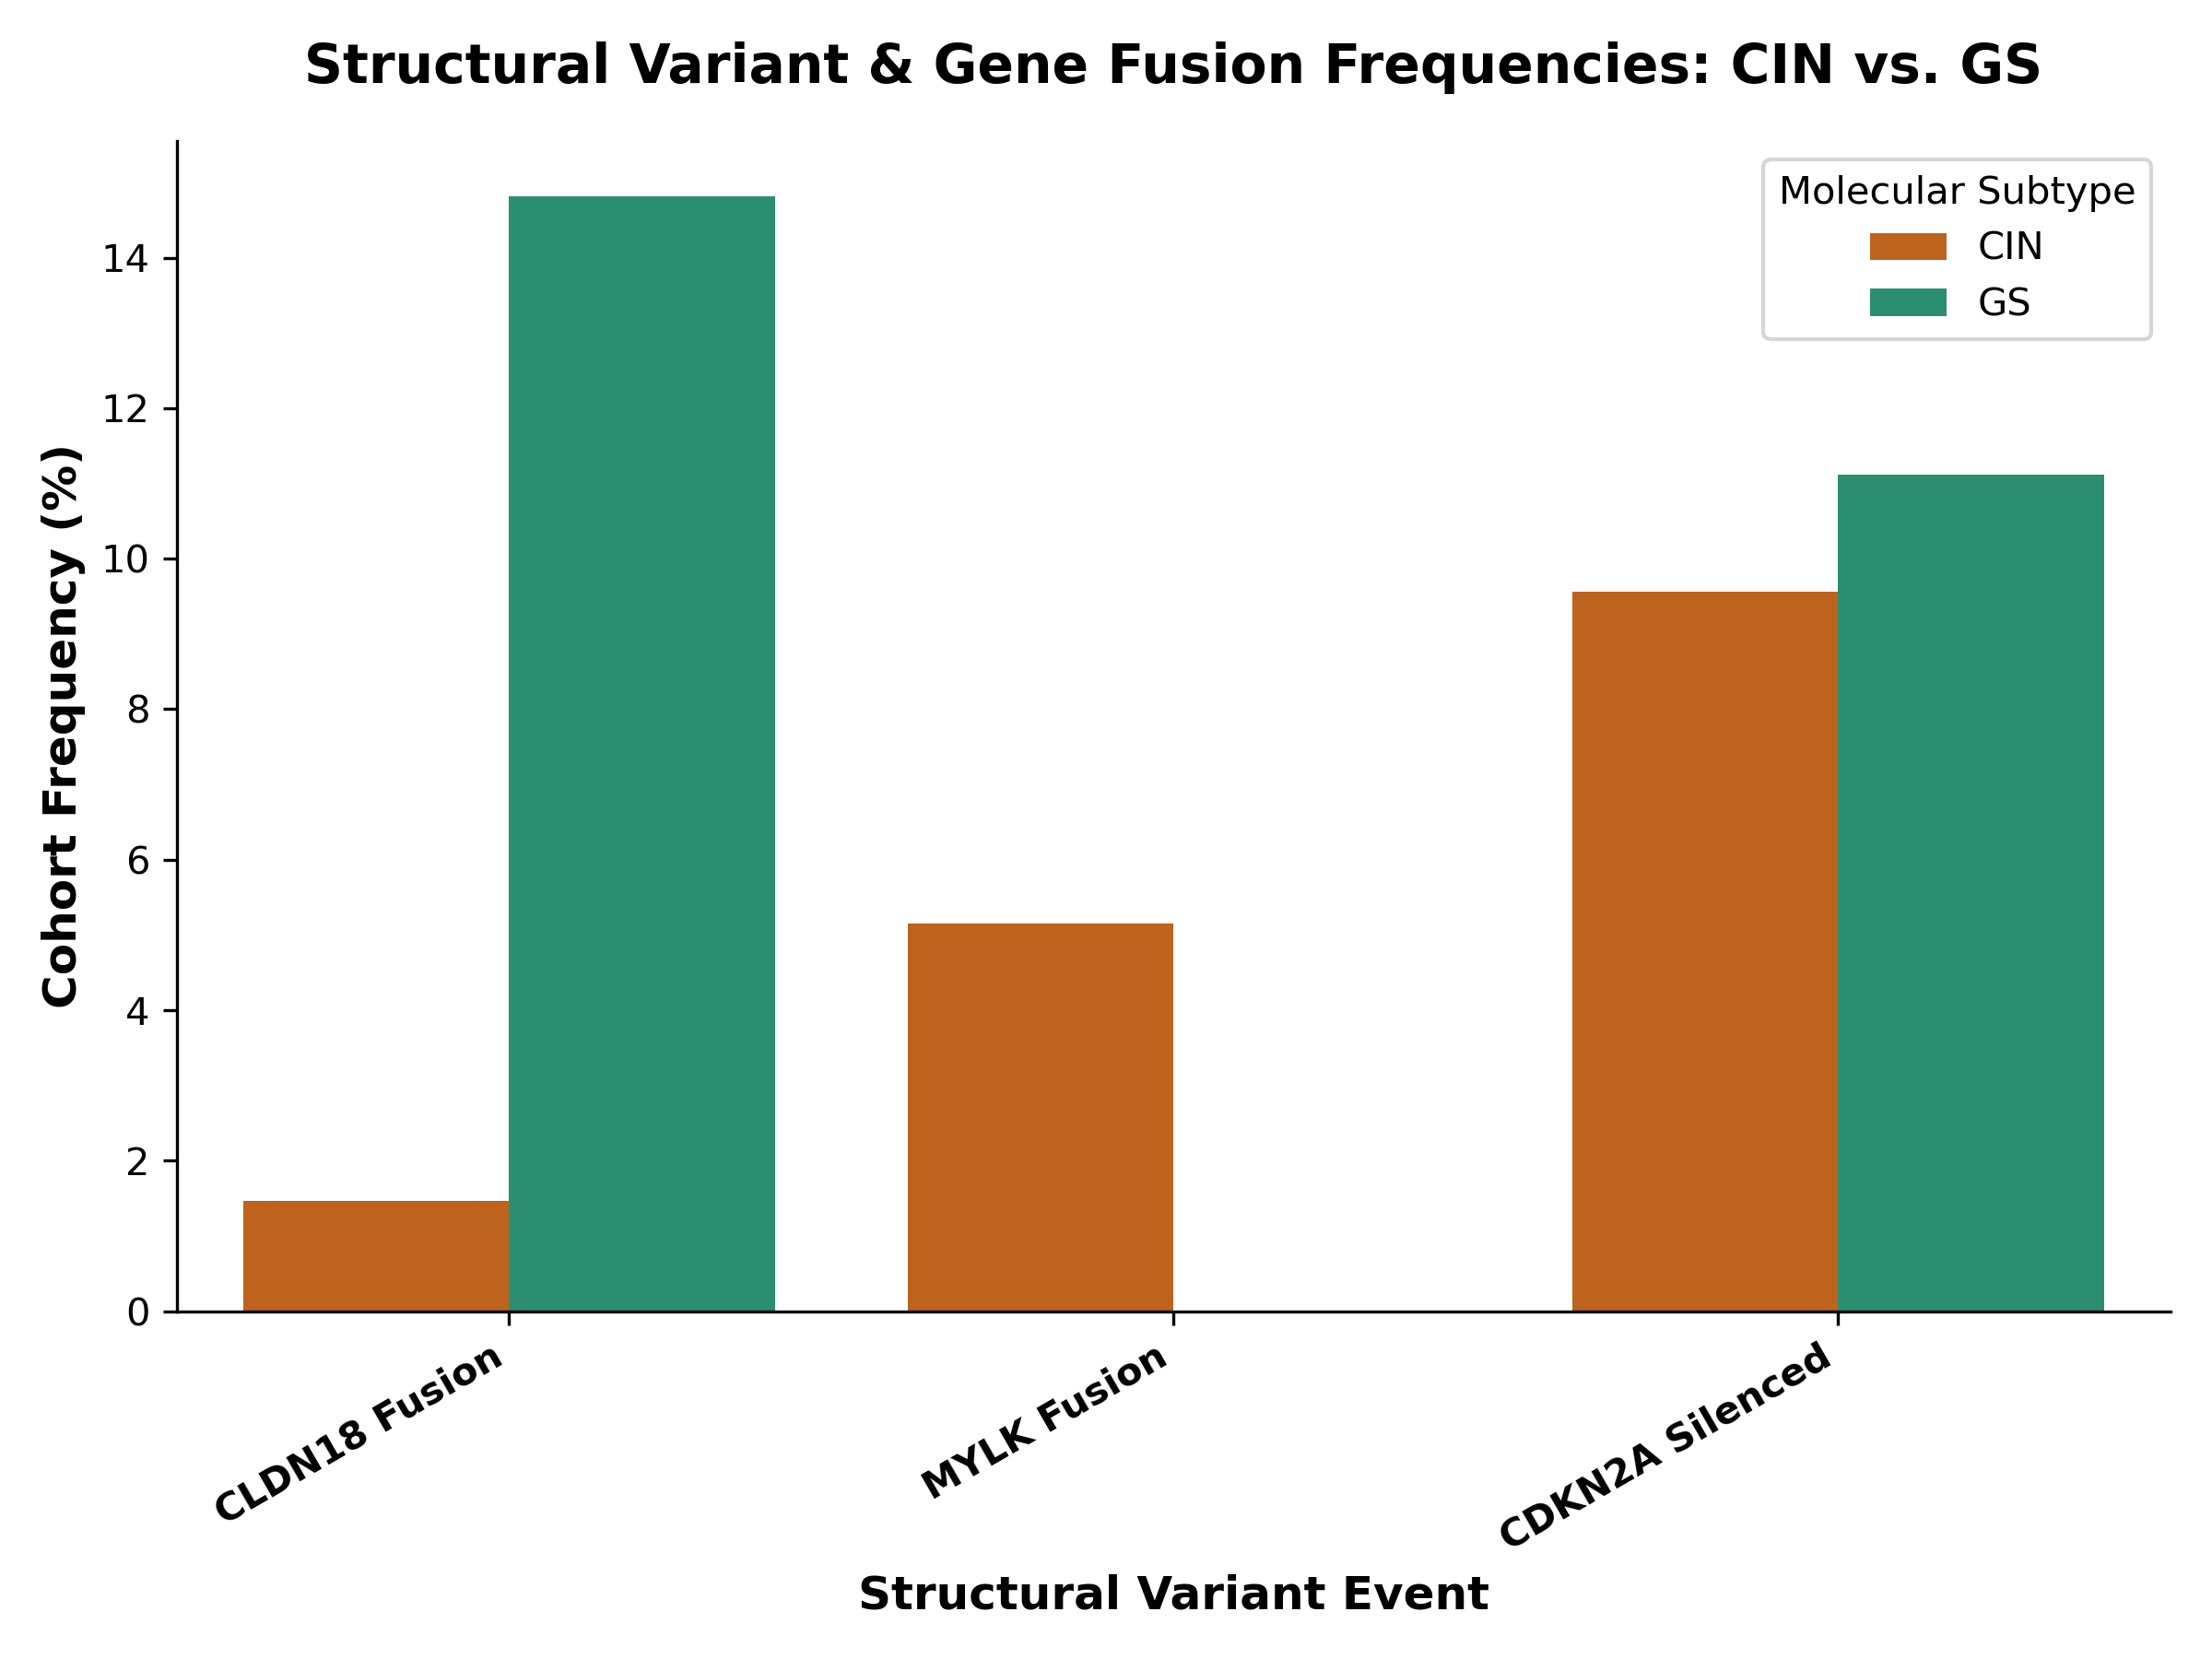

In [11]:
sv_matrix_path = os.path.join(RESULTS_DIR, "sv_events_matrix.csv")
sv_summary_path = os.path.join(RESULTS_DIR, "structural_variant_summary.csv")

sv_matrix_df = pd.read_csv(sv_matrix_path, index_col=0)
sv_summary_df = pd.read_csv(sv_summary_path)

print(f"Structural Variant Matrix shape: {sv_matrix_df.shape} (samples x events).")
print("\nStructural Variant & Gene Fusion Summary:")
display(sv_summary_df)

sv_fig = os.path.join(FIGURES_DIR, "structural_variants_distribution.png")
if os.path.exists(sv_fig):
    display(Image(filename=sv_fig))


### 9. Export Integrated Multi-Modal Feature Matrix Store for Phase 3

In [12]:
# Combine TF Activity Scores, FGA Burden, Mutational Signature Exposures, and SV Events
common_samples = tf_acts.index.intersection(meta_df.index)

feature_store = tf_acts.loc[common_samples].copy()

# Add FGA
if "FGA" in fga_df.columns:
    feature_store["FGA_Burden"] = fga_df["FGA"].reindex(common_samples).fillna(0.0)

# Add Mutational Signature Exposures
for col in mut_sig_df.columns:
    feature_store[f"MutSig_{col}"] = mut_sig_df[col].reindex(common_samples).fillna(0.0)

# Add Structural Variants & Fusions
for col in sv_matrix_df.columns:
    feature_store[col] = sv_matrix_df[col].reindex(common_samples).fillna(0)

# Add Target Labels
feature_store["MOLECULAR_SUBTYPE"] = meta_df.loc[common_samples, "MOLECULAR_SUBTYPE"]
feature_store["SUBTYPE_CIN_VS_GS"] = (feature_store["MOLECULAR_SUBTYPE"] == "CIN").astype(int)

out_store_path = os.path.join(RESULTS_DIR, "phase2_integrated_feature_store.csv")
feature_store.to_csv(out_store_path)

print(f"Integrated Multi-Modal Phase 2 Feature Store exported successfully to: {out_store_path}")
print(f"Final shape: {feature_store.shape[0]} samples x {feature_store.shape[1]} features.")


Integrated Multi-Modal Phase 2 Feature Store exported successfully to: /media/parth/Research_Volume/GS_vs_CIN/results/phase2_integrated_feature_store.csv
Final shape: 190 samples x 309 features.
